# The Geometry of Optimization

### From a Brute-Force Search to Adam and Why the Ranking of Optimizers Is Not a Property of the Optimizers

**Kushal Kharel**

---

Training a model is an act of search. We have a function that scores how wrong we
are, a set of parameters we are allowed to move and no map. Everything that
follows, every optimizer in this notebook is a different answer to the same
question: *given only local information about the loss, which way should I step?*

This notebook develops that answer from nothing. It begins with a search
strategy so crude it barely deserves the name, extracts from its failure the idea
of a derivative, builds gradient descent and then follows the historical arc of
repairs: stochastic sampling, mini-batching, momentum, adaptive step sizes and
finally Adam, deriving each one rather than quoting it.

Then it does something most treatments of this material do not. Having built the
ladder, it **tests whether the ladder is real.**

The conclusion the ladder invites is that Adam is best and plain gradient descent
is a historical curiosity. Part III designs a controlled experiment to check
that and finds it is not true in any regime-independent sense. Across three loss
surfaces that differ *only* in how the input features were generated, plain batch
gradient descent, RMSProp and Adam each win decisively somewhere and each lose
decisively somewhere else. The ranking turns out to be a property of the
**curvature of the loss surface** and not of the algorithms.

That finding also indicts the standard demonstration including the one in the
first two parts of this notebook. Standardizing the features which every
tutorial does as boilerplate preprocessing drives the condition number of the
problem to approximately 1 and at a condition number of 1 every first-order
method converges at essentially the same rate. The usual demo deletes the exact
pathology that motivated inventing momentum and RMSProp in the first place.

---

### How to read this

| Part | Contents |
|---|---|
| **0** | Setup, and the reproducibility discipline this notebook commits to |
| **I** | One variable: brute force -> derivative -> gradient descent -> the learning rate solved exactly |
| **II** | Many parameters, limited budget: SGD, mini-batch, momentum, RMSProp, Adam |
| **III** | The controlled experiment and what it overturns |
| **IV** | Limitations and what would have to be done next |

Everything runs top to bottom on a fresh kernel with no hidden state. Every
numerical claim is either computed in a cell or derivable by hand and the
hand-derivable ones are marked **[verify by hand]** so you can check the code is
telling the truth.

**Requirements:** `numpy`, `matplotlib`, `pandas`, `scipy`, `scikit-learn`.

---

# Part 0 · Setup and one commitment about randomness

Before any mathematics, one piece of discipline, because it silently invalidates
more computational results than any error of reasoning.

## The failure

The familiar idiom is to call `np.random.seed(42)` once at the top of a notebook
and treat the run as reproducible. It is not. `np.random.seed` sets a **single
global counter** shared by every random call in the process and that counter
advances every time anything draws from it. Reproducibility therefore depends
not just on the seed but on **the exact order and number of every random call
since the seed was set** which in a notebook means it depends on the order we
clicked cells.

Re-run one data-generating cell without re-running the seed cell and we are
silently working with a different sample. Nothing errors. The plots still render.

The cell below demonstrates it and shows the fix.

In [2]:
import numpy as np

print("Global seed, data line executed twice (the notebook failure mode)")
np.random.seed(42)
print("first execution : ", np.random.normal(0, 1, 3).round(4))
print("'cell re-run' :", np.random.normal(0, 1, 3).round(4), "<-- different sample")

print("\nLocal generator, created where the data is made (the fix)")

def draw(seed):
    rng = np.random.default_rng(seed)      # a fresh, independent stream
    return rng.normal(0, 1, 3)

print("call 1:", draw(42).round(4))
print("call 2:", draw(42).round(4), " <-- identical, in any execution order")

Global seed, data line executed twice (the notebook failure mode)
first execution :  [ 0.4967 -0.1383  0.6477]
'cell re-run' : [ 1.523  -0.2342 -0.2341] <-- different sample

Local generator, created where the data is made (the fix)
call 1: [ 0.3047 -1.04    0.7505]
call 2: [ 0.3047 -1.04    0.7505]  <-- identical, in any execution order


## The commitment

Every random quantity in this notebook comes from a **local**
`np.random.default_rng(seed)` created at the point of use. The global state is
never touched. The practical consequence: we may run any cell in any order, any
number of times and every number we see will be the number we get.

This is not fussiness. It is the difference between a result and an anecdote.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# A consistent colour per method, used in every figure from here on.
PALETTE = {
    "Batch GD":   "#4C4C4C",
    "SGD":        "#E4572E",
    "Mini-batch": "#F3A712",
    "Momentum":   "#2E86AB",
    "RMSProp":    "#57A773",
    "Adam":       "#8B2FC9",
}

print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.0.2 | pandas 2.2.2


---
---

# Part I · One variable

We start with the smallest problem that still contains the whole idea:

$$\min_{x \in \mathbb{R}} \; f(x), \qquad f(x) = x^2$$

We know the answer is $x^\star = 0$. That is the point, a problem with a known
answer is the only kind on which we can *check* a method rather than merely run
it. Every technique below will be judged against the truth we already hold.

## 1.1 · The crudest possible search and its three failures

The most direct thing we can do with a function we can evaluate is evaluate it
in a lot of places and keep the best. No calculus, no theory.

In [4]:
def f(x):
    return x ** 2

def brute_force_min(f, x_values):
    """Return the grid point with the lowest function value."""
    values = f(np.asarray(x_values))
    return x_values[np.argmin(values)]

coarse = np.linspace(-2, 2, 20)      # 20 points
fine   = np.linspace(-2, 2, 2001)    # 2001 points
narrow = np.linspace(1, 3, 20)       # a grid that misses the minimum entirely

for label, grid in [("coarse (20 pts)", coarse), ("fine   (2001 pts)", fine), ("narrow (misses x*)", narrow)]:
    x_hat = brute_force_min(f, grid)
    print(f"{label:<20} argmin = {x_hat:+.5f}   |error| = {abs(x_hat - 0):.5f}")

coarse (20 pts)      argmin = +0.10526   |error| = 0.10526
fine   (2001 pts)    argmin = +0.00000   |error| = 0.00000
narrow (misses x*)   argmin = +1.00000   |error| = 1.00000


Three separate failures and they matter because each one motivates a specific
feature of what replaces this.

**Failure 1: the answer must already be inside our grid.** The narrow grid
returns $x = 1$ with total confidence. It has no way to express *"the minimum is
somewhere to the left of everything I looked at."* Brute force cannot extrapolate.

**Failure 2: accuracy is capped by spacing we chose in advance.** The coarse
grid is off by 0.105 because it has no point at zero. To do better we must
already know how much better we need to do.

**Failure 3: the cost is in the wrong place.** The fine grid spends 2001
evaluations and roughly 2000 of them are on points that were obviously bad. In
two dimensions at the same resolution that becomes $2001^2$, in ten dimensions
$2001^{10}$. This is the curse of dimensionality and it is fatal: no realistic model
has few enough parameters for grid search.

Notice that all three failures share a single root cause. We chose **every**
point before looking at **any** result. The fix is to choose the next point using
what the last one told us and for that we need the function to tell us
something directional.

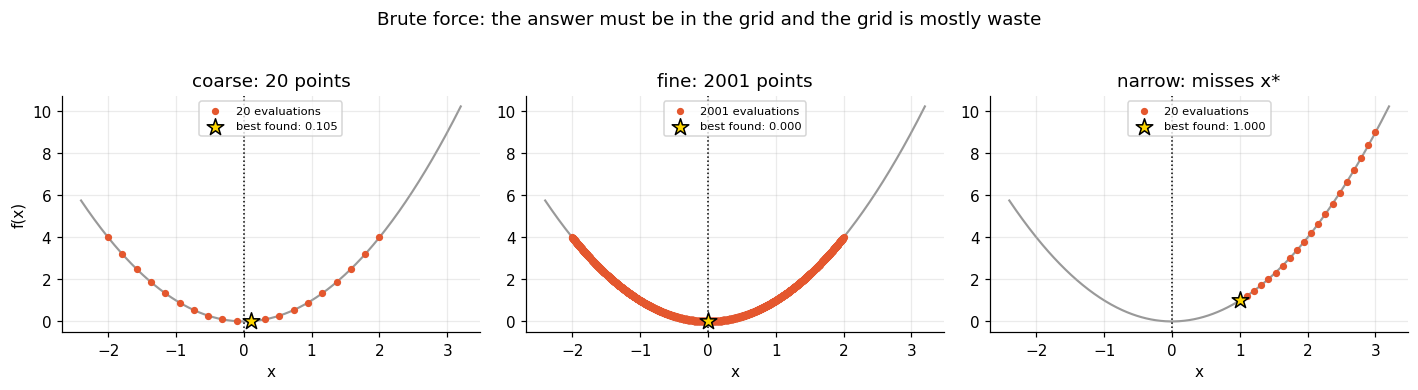

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
x_plot = np.linspace(-2.4, 3.2, 400)

for ax, (label, grid) in zip(axes, [("coarse: 20 points", coarse), ("fine: 2001 points", fine), ("narrow: misses x*", narrow)]):
    ax.plot(x_plot, f(x_plot), color="#999", lw=1.4, zorder=1)
    ax.scatter(grid, f(grid), s=14, color="#E4572E", zorder=3, label=f"{len(grid)} evaluations")
    best = brute_force_min(f, grid)
    ax.scatter([best], [f(best)], s=130, marker="*", color="gold", edgecolor="black", zorder=5, label=f"best found: {best:.3f}")
    ax.axvline(0, color="black", ls=":", lw=1)
    ax.set_title(label)
    ax.set_xlabel("x")
    ax.legend(fontsize=7.5, loc="upper center")

axes[0].set_ylabel("f(x)")
fig.suptitle("Brute force: the answer must be in the grid and the grid is mostly waste", y=1.03)
plt.tight_layout()
plt.show()

## 1.2 · The derivative and how to compute one we can trust

The directional information we need is the derivative. Its sign tells us which
way the function falls and its magnitude tells us how fast.

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

In practice we cannot take a limit so we pick a small $h$. **Which finite
difference we choose is not a detail** and this is worth doing carefully because
the wrong choice produces a derivative that is visibly offset from the truth.

**Forward difference**: the literal translation of the definition:

$$D_+ f(x) = \frac{f(x+h) - f(x)}{h}$$

**Central difference**: step both ways and average:

$$D_0 f(x) = \frac{f(x+h) - f(x-h)}{2h}$$

Both cost two function evaluations. They do not cost the same in accuracy. Expand
in a Taylor series:

$$D_+ f(x) = f'(x) + \tfrac{h}{2} f''(x) + O(h^2) \qquad\quad
  D_0 f(x) = f'(x) + \tfrac{h^2}{6} f^{(3)}(x) + O(h^4)$$

The forward difference carries an error **proportional to $h$**; the central
difference's leading error term cancels leaving one proportional to $h^2$. At
$h = 10^{-4}$ that is the difference between an error near $10^{-4}$ and one near
$10^{-8}$: four orders of magnitude for free.

**[verify by hand]** For $f(x) = x^3$ at $x = 1$:

$$D_+ = \frac{(1+h)^3 - 1}{h} = 3 + 3h + h^2 \quad\Rightarrow\quad \text{error} \approx 3h$$
$$D_0 = \frac{(1+h)^3 - (1-h)^3}{2h} = \frac{6h + 2h^3}{2h} = 3 + h^2 \quad\Rightarrow\quad \text{error} = h^2$$

The table below should reproduce exactly that.

In [6]:
def forward_difference(g, x, h):
    return (g(x + h) - g(x)) / h

def central_difference(g, x, h):
    return (g(x + h) - g(x - h)) / (2 * h)

cube = lambda x: x ** 3
x0, truth = 1.0, 3.0

rows = []
for h in [1e-1, 1e-2, 1e-3, 1e-4, 1e-6, 1e-8]:
    fwd = forward_difference(cube, x0, h)
    cen = central_difference(cube, x0, h)
    rows.append({
        "h": h,
        "forward": fwd,
        "|err| fwd": abs(fwd - truth),
        "predicted 3h": 3 * h,
        "central": cen,
        "|err| cen": abs(cen - truth),
        "predicted h^2": h ** 2,
    })

table = pd.DataFrame(rows).set_index("h")
print("f(x) = x^3  at  x = 1,   true derivative = 3\n")
print(table.to_string(float_format=lambda v: f"{v:.3e}"))

f(x) = x^3  at  x = 1,   true derivative = 3

               forward  |err| fwd  predicted 3h   central  |err| cen  predicted h^2
h                                                                                  
1.000000e-01 3.310e+00  3.100e-01     3.000e-01 3.010e+00  1.000e-02      1.000e-02
1.000000e-02 3.030e+00  3.010e-02     3.000e-02 3.000e+00  1.000e-04      1.000e-04
1.000000e-03 3.003e+00  3.001e-03     3.000e-03 3.000e+00  1.000e-06      1.000e-06
1.000000e-04 3.000e+00  3.000e-04     3.000e-04 3.000e+00  9.999e-09      1.000e-08
1.000000e-06 3.000e+00  3.000e-06     3.000e-06 3.000e+00  8.027e-11      1.000e-12
1.000000e-08 3.000e+00  3.972e-09     3.000e-08 3.000e+00  7.130e-09      1.000e-16


The forward error tracks $3h$ and the central error tracks $h^2$ across four
orders of magnitude exactly as the Taylor expansion predicts. Then the central
column stops obeying: at $h=10^{-6}$ it is already ~80× worse than $h^2$
predicts and by $h=10^{-8}$ it is *worse than it was at* $h=10^{-4}$.

That reversal is not a bug and it is worth understanding because it is the
single most common trap in numerical differentiation. Two error sources compete:

- **Truncation error** falls as $h$ shrinks ($O(h^2)$ here).
- **Round-off error** *grows* as $h$ shrinks. We subtract two nearly equal
  numbers and then divide by a tiny one so catastrophic cancellation amplifies
  floating-point noise by roughly $\varepsilon_{\text{machine}} / h$.

The total is minimized somewhere in the middle, near $h \approx \varepsilon^{1/3}
\approx 6 \times 10^{-6}$ for a central difference. **Smaller $h$ is not
uniformly better** and a plot of error versus $h$ is V-shaped, not monotone.

For the rest of this notebook we use analytic derivatives which have neither
error. Finite differences remain indispensable for one purpose: **checking** that
an analytic derivative is correct. That check appears in Part II.

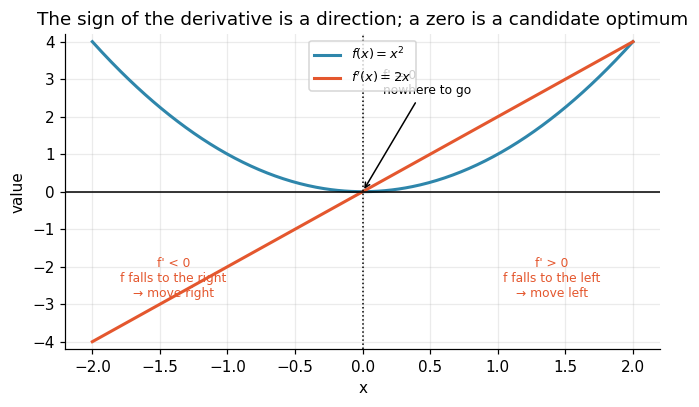

In [7]:
def df(x):
    """Analytic derivative of f(x) = x**2."""
    return 2 * x

x_plot = np.linspace(-2, 2, 400)

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(x_plot, f(x_plot), label="$f(x) = x^2$", color="#2E86AB", lw=2)
ax.plot(x_plot, df(x_plot), label="$f'(x) = 2x$", color="#E4572E", lw=2)
ax.axhline(0, color="black", lw=1)
ax.axvline(0, color="black", ls=":", lw=1)
ax.annotate("f' < 0\nf falls to the right\n→ move right", xy=(-1.4, -2.8), fontsize=8, ha="center", color="#E4572E")
ax.annotate("f' > 0\nf falls to the left\n→ move left", xy=(1.4, -2.8), fontsize=8, ha="center", color="#E4572E")
ax.annotate("f' = 0\nnowhere to go", xy=(0, 0), xytext=(0.15, 2.6), fontsize=8, arrowprops=dict(arrowstyle="->", lw=1))
ax.set_xlabel("x")
ax.set_ylabel("value")
ax.set_ylim(-4.2, 4.2)
ax.legend(loc="upper center", fontsize=8.5)
ax.set_title("The sign of the derivative is a direction; a zero is a candidate optimum")
plt.tight_layout()
plt.show()

## 1.3 · Why a step in that direction is justified

Knowing which way to walk does not by itself justify walking. What licenses the
step is the **first-order Taylor approximation**: near a point $x_0$, the tangent
line is a usable stand-in for $f$.

$$f(x) \;\approx\; \ell(x) = f(x_0) + f'(x_0)\,(x - x_0)$$

with error $\tfrac{1}{2} f''(\xi)(x-x_0)^2$ for some $\xi$ between the two points, that is, error growing with the **square** of how far we move.

That quadratic is the entire theory of the learning rate in one term. Take a
small step and the approximation is excellent and the step is nearly free. Take a
large step and the error grows quadratically until the tangent tells us nothing
about the function we are actually on.

Let us measure it rather than assert it.

In [8]:
x0 = 1.0
slope, intercept_value = df(x0), f(x0)
tangent = lambda x: intercept_value + slope * (x - x0)

print(f"Tangent at x0 = {x0}:   l(x) = {intercept_value:.1f} + {slope:.1f}(x - {x0:.1f})\n")
print(f"{'step':>8} {'l(x0-s)':>12} {'f(x0-s)':>12} {'|error|':>12} {'error/step^2':>14}")
print("-" * 62)
for step in [0.5, 0.2, 0.1, 0.05, 0.01]:
    x_new = x0 - step
    approx, exact = tangent(x_new), f(x_new)
    err = abs(approx - exact)
    print(f"{step:>8.2f} {approx:>12.5f} {exact:>12.5f} {err:>12.6f} {err/step**2:>14.4f}")

Tangent at x0 = 1.0:   l(x) = 1.0 + 2.0(x - 1.0)

    step      l(x0-s)      f(x0-s)      |error|   error/step^2
--------------------------------------------------------------
    0.50      0.00000      0.25000     0.250000         1.0000
    0.20      0.60000      0.64000     0.040000         1.0000
    0.10      0.80000      0.81000     0.010000         1.0000
    0.05      0.90000      0.90250     0.002500         1.0000
    0.01      0.98000      0.98010     0.000100         1.0000


**[verify by hand]** The final column is exactly 1.0 at every step size, and it
should be: for $f(x)=x^2$ the second-order Taylor remainder is
$\tfrac{1}{2}f''(\xi)\,s^2 = \tfrac{1}{2}(2)s^2 = s^2$, so error/step² $= 1$
identically. Halving the step quarters the error.

This is the bargain gradient descent strikes. The derivative is only locally
valid, so take a step short enough that "locally" still applies, then recompute.
The step size $\alpha$ is precisely how much we trust the tangent.

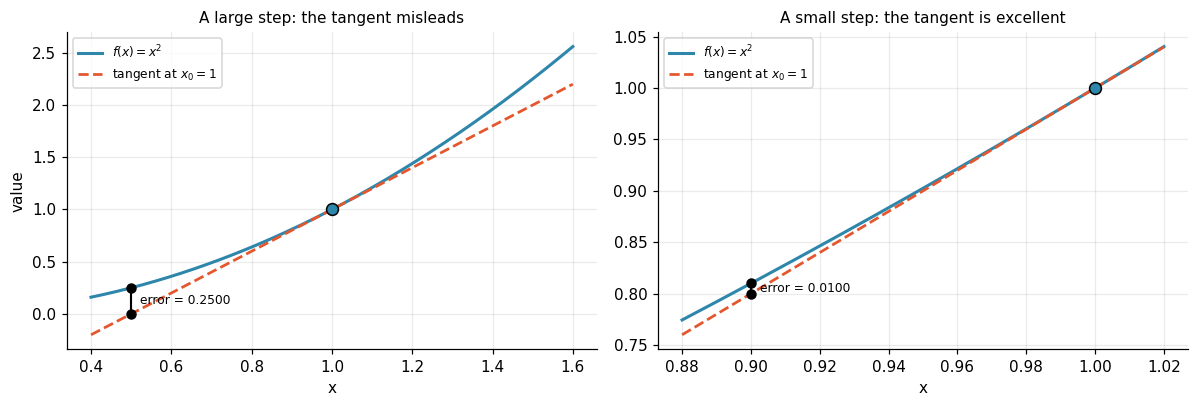

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
x_near = np.linspace(0.4, 1.6, 300)

for ax, (lo, hi, title) in zip(axes, [(0.4, 1.6, "A large step: the tangent misleads"), (0.88, 1.02, "A small step: the tangent is excellent")]):
    xs = np.linspace(lo, hi, 300)
    ax.plot(xs, f(xs), color="#2E86AB", lw=2, label="$f(x) = x^2$")
    ax.plot(xs, tangent(xs), color="#E4572E", lw=1.8, ls="--", label="tangent at $x_0=1$")
    step = 0.5 if lo < 0.5 else 0.1
    xn = x0 - step
    if lo <= xn <= hi:
        ax.plot([xn, xn], [tangent(xn), f(xn)], color="black", lw=1.4)
        ax.scatter([xn, xn], [tangent(xn), f(xn)], s=34, color="black", zorder=5)
        ax.annotate(f"error = {abs(tangent(xn)-f(xn)):.4f}", xy=(xn, (tangent(xn) + f(xn)) / 2), xytext=(6, 0), textcoords="offset points", fontsize=8, va="center")
    ax.scatter([x0], [f(x0)], s=60, color="#2E86AB", zorder=6, edgecolor="black")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x")
    ax.legend(fontsize=8)

axes[0].set_ylabel("value")
plt.tight_layout()
plt.show()

## 1.4 · Gradient descent

Everything is now in place. Stand somewhere, compute the slope, step against it,
repeat:

$$\boxed{\;x_{t+1} = x_t - \alpha\, f'(x_t)\;}$$

The minus sign is the whole algorithm: $f'$ points uphill, and we want down.

In [10]:
def gradient_descent_1d(df, x_init, learning_rate, n_steps=50, tol=1e-10):
    """
    Minimize a scalar function given its derivative.

    Returns the full trajectory, including the starting point, so the path can
    be plotted rather than only the endpoint reported.
    """
    x = float(x_init)
    history = [x]
    for _ in range(n_steps):
        x_new = x - learning_rate * df(x)
        history.append(x_new)
        if abs(x_new - x) < tol:
            break
        x = x_new
    return np.array(history)

path = gradient_descent_1d(df, x_init=6.0, learning_rate=0.3, n_steps=25)
print(f"start      x = {path[0]:.6f}")
print(f"after 5    x = {path[5]:.6f}")
print(f"after 25   x = {path[-1]:.3e}")
print(f"steps taken: {len(path) - 1}")

start      x = 6.000000
after 5    x = 0.061440
after 25   x = 6.755e-10
steps taken: 25


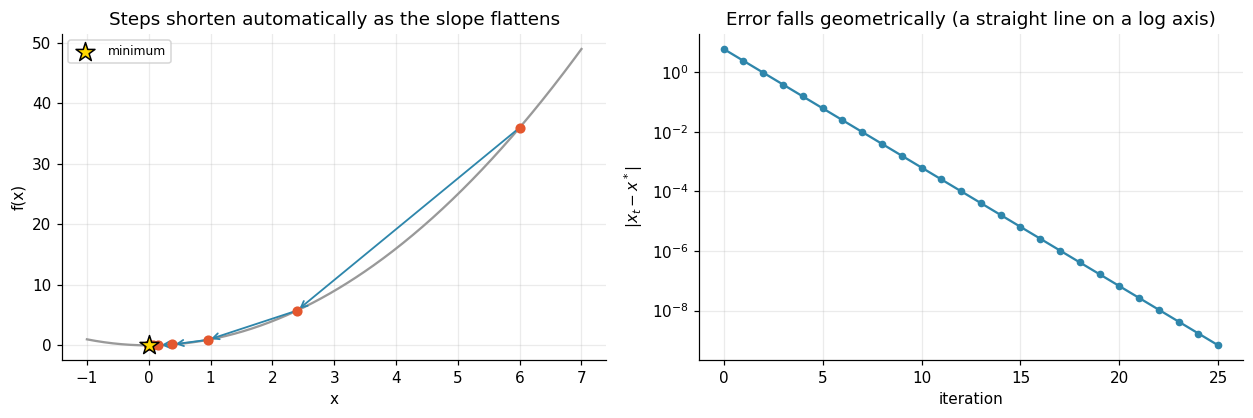

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))

xs = np.linspace(-1, 7, 400)
axes[0].plot(xs, f(xs), color="#999", lw=1.5)
axes[0].scatter(path, f(path), s=32, color="#E4572E", zorder=5)
for a, b in zip(path[:-1], path[1:]):
    axes[0].annotate("", xy=(b, f(b)), xytext=(a, f(a)), arrowprops=dict(arrowstyle="->", color="#2E86AB", lw=1.2))
axes[0].scatter([0], [0], s=170, marker="*", color="gold", edgecolor="black", zorder=6, label="minimum")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].set_title("Steps shorten automatically as the slope flattens")
axes[0].legend(fontsize=8)

axes[1].semilogy(np.abs(path), "o-", color="#2E86AB", ms=4)
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("$|x_t - x^*|$")
axes[1].set_title("Error falls geometrically (a straight line on a log axis)")

plt.tight_layout()
plt.show()

Two features of the left panel are worth naming because both are automatic and
both are easy to miss.

**The steps shrink on their own.** Nothing schedules that. The step length is
$\alpha |f'(x_t)|$, and $|f'|$ is small near the optimum so the method
decelerates into the minimum without being told to.

**The right panel is a straight line on a log scale.** That means the error is
multiplied by a constant factor each iteration: *geometric* (or *linear*)
convergence. The value of that factor is the subject of the next section and it
turns out to be the single most important number in this entire notebook.

## 1.5 · The learning rate solved exactly

Most treatments say the learning rate must be "not too big, not too small" and
show three cartoons. For $f(x) = x^2$ we can do considerably better than a
cartoon: we can solve it in closed form and predict every behaviour before
running anything.

Substituting $f'(x) = 2x$ into the update:

$$x_{t+1} = x_t - \alpha(2 x_t) = (1 - 2\alpha)\, x_t
\qquad\Longrightarrow\qquad
\boxed{\; x_t = (1 - 2\alpha)^t\, x_0 \;}$$

The entire dynamics is one number, $r = 1 - 2\alpha$, raised to a power. Every
qualitative regime follows from where $r$ sits:

| range of $\alpha$ | $r = 1-2\alpha$ | behaviour |
|---|---|---|
| $0 < \alpha < 0.5$ | $0 < r < 1$ | monotone decay, no sign change |
| $\alpha = 0.5$ | $r = 0$ | **exact minimum in one step** |
| $0.5 < \alpha < 1$ | $-1 < r < 0$ | overshoots, alternates sign, still converges |
| $\alpha = 1$ | $r = -1$ | oscillates forever between $\pm x_0$ |
| $\alpha > 1$ | $|r| > 1$ | diverges |

**[verify by hand]** With $x_0 = 2$ and $\alpha = 0.1$: $r = 0.8$, so
$x_5 = 2(0.8)^5 = 2(0.32768) = 0.65536$. The table below prints exactly that.

The general statement, for a quadratic with curvature $L = f''$, is that gradient
descent is stable if and only if

$$\alpha < \frac{2}{L}.$$

Here $L = 2$, giving $\alpha < 1$. **Hold on to this.** In Part III, $L$ becomes
the largest eigenvalue of a Hessian matrix, the same formula governs stability in
many dimensions, and the *ratio* of the largest to the smallest eigenvalue turns
out to explain the entire experimental result.

In [12]:
x_start = 2.0
alphas = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0, 1.05]

records = []
for a in alphas:
    traj = gradient_descent_1d(df, x_init=x_start, learning_rate=a, n_steps=30, tol=0)
    r = 1 - 2 * a
    records.append({
        "alpha": a,
        "r = 1-2a": r,
        "x_5 (measured)": traj[5],
        "x_5 = r^5 * x0": r ** 5 * x_start,
        "x_30": traj[30],
        "behaviour": ("one-step exact" if abs(r) < 1e-12 else
                      "monotone decay" if 0 < r < 1 else
                      "oscillating decay" if -1 < r < 0 else
                      "permanent oscillation" if abs(r + 1) < 1e-12 else
                      "divergence"),
    })

df_lr = pd.DataFrame(records).set_index("alpha")
print(f"f(x) = x^2,  x0 = {x_start},  stability requires alpha < 2/f'' = 1.0\n")
print(df_lr.to_string(float_format=lambda v: f"{v:>12.5g}"))

f(x) = x^2,  x0 = 2.0,  stability requires alpha < 2/f'' = 1.0

          r = 1-2a  x_5 (measured)  x_5 = r^5 * x0         x_30              behaviour
alpha                                                                                 
0.10           0.8         0.65536         0.65536    0.0024759         monotone decay
0.30           0.4         0.02048         0.02048   2.3058e-12         monotone decay
0.50             0               0               0            0         one-step exact
0.70          -0.4        -0.02048        -0.02048   2.3058e-12      oscillating decay
0.90          -0.8        -0.65536        -0.65536    0.0024759      oscillating decay
1.00            -1              -2              -2            2  permanent oscillation
1.05          -1.1          -3.221          -3.221       34.899             divergence


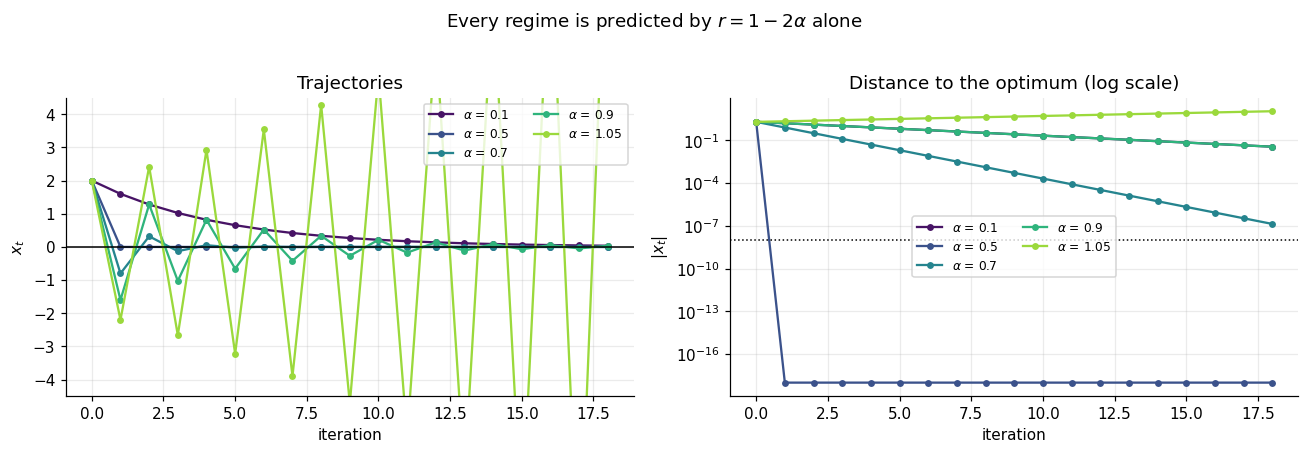

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
show = [0.1, 0.5, 0.7, 0.9, 1.05]
colors = plt.cm.viridis(np.linspace(0.05, 0.85, len(show)))

for a, c in zip(show, colors):
    traj = gradient_descent_1d(df, x_init=x_start, learning_rate=a, n_steps=18, tol=0)
    axes[0].plot(traj, "o-", ms=3.5, color=c, label=f"$\\alpha$ = {a}")
    axes[1].semilogy(np.abs(traj) + 1e-18, "o-", ms=3.5, color=c, label=f"$\\alpha$ = {a}")

axes[0].axhline(0, color="black", lw=1)
axes[0].set_ylim(-4.5, 4.5)
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("$x_t$")
axes[0].set_title("Trajectories")
axes[0].legend(fontsize=8, ncol=2)

axes[1].axhline(1e-8, color="black", ls=":", lw=1)
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("$|x_t|$")
axes[1].set_title("Distance to the optimum (log scale)")
axes[1].legend(fontsize=8, ncol=2)

fig.suptitle(r"Every regime is predicted by $r = 1 - 2\alpha$ alone", y=1.02)
plt.tight_layout(); plt.show()

The $\alpha = 0.5$ curve deserves a comment because it looks like cheating. It
reaches the exact minimum in one step. It is not cheating but rather it is a preview of
second-order methods. For a quadratic, the Newton step $\alpha = 1/f''$ lands on
the optimum immediately and $1/f'' = 1/2$ here.

That is the ideal case gradient descent can never rely on: **one perfect step
size exists but only because we know the curvature.** Every method in Part II is
in some sense an attempt to estimate that curvature cheaply from gradients alone.

## 1.6 · Many parameters

Nothing conceptual changes when $x$ becomes a vector $\theta \in \mathbb{R}^d$.
The derivative becomes the gradient: the vector of partial derivatives:

$$\nabla J(\theta) = \Big[\tfrac{\partial J}{\partial \theta_1},\;
\tfrac{\partial J}{\partial \theta_2},\; \dots,\;
\tfrac{\partial J}{\partial \theta_d}\Big]^{\!\top}$$

and the update becomes vector-valued:

$$\theta_{t+1} = \theta_t - \alpha \nabla J(\theta_t)$$

The gradient points in the direction of **steepest ascent** so its negation is
the steepest descent direction. One caveat that will matter enormously in Part
III: *steepest* is measured in the Euclidean metric and "steepest" is not the
same as "toward the minimum" unless the level sets happen to be circles.

### The cost function and a convention we will hold to

For linear regression with $n$ observations we use mean squared error:

$$J(\theta) = \frac{1}{n}\sum_{i=1}^{n} \big(x_i^{\!\top}\theta - y_i\big)^2
= \frac{1}{n}\lVert X\theta - y \rVert^2
\qquad\Longrightarrow\qquad
\nabla J(\theta) = \frac{2}{n} X^{\!\top}(X\theta - y)$$

A note on the factor of 2 because it is a genuine source of confusion. Many
texts define $J$ with $\frac{1}{2n}$ specifically so the 2 from differentiating
the square cancels and the gradient comes out as $\frac{1}{n}X^\top(X\theta-y)$.
Both conventions are correct; they differ by a factor of 2 which is absorbed
into the learning rate and changes nothing.

What is **not** acceptable is mixing them: stating $\frac{1}{2n}$ in the text and
implementing $\frac{1}{n}$ in the code. That silently doubles the effective
learning rate relative to what a reader following the derivation expects. This
notebook uses $\frac{1}{n}$ for the loss and $\frac{2}{n}$ for the gradient,
everywhere without exception.

In [14]:
def make_linear_data(n_samples=2000, noise_std=3.0, beta=(3.0, -0.7), seed=0):
    """
    Synthetic two-feature linear regression problem.

    The target is mean-centred, which forces the optimal intercept to zero. That
    costs nothing statistically and buys a great deal visually: with the bias
    pinned at zero, a two-feature problem needs only three dimensions to draw
    (w1, w2, loss) instead of four.
    """
    rng = np.random.default_rng(seed)
    beta = np.asarray(beta, dtype=float)

    x1 = rng.normal(0, 1, n_samples)
    x2 = rng.normal(0, 5, n_samples)
    X_raw = np.column_stack([x1, x2])
    y_raw = X_raw @ beta + rng.normal(0, noise_std, n_samples)

    X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
    y = y_raw - y_raw.mean()
    return X, y, X_raw, y_raw, beta


X, y, X_raw, y_raw, beta_true = make_linear_data()
print(f"X shape {X.shape},  y shape {y.shape}")
print(f"generating coefficients (raw units): {beta_true}")
print(f"feature means after standardising: {X.mean(axis=0).round(12)}")
print(f"feature stds  after standardising: {X.std(axis=0).round(12)}")

X shape (2000, 2),  y shape (2000,)
generating coefficients (raw units): [ 3.  -0.7]
feature means after standardising: [-0. -0.]
feature stds  after standardising: [1. 1.]


### The closed-form solution and how to compute it properly

Linear regression has an exact answer. Setting $\nabla J = 0$:

$$\frac{2}{n}X^{\!\top}(X\theta - y) = 0
\;\Longrightarrow\;
X^{\!\top}X\,\theta = X^{\!\top}y
\;\Longrightarrow\;
\theta^\star = (X^{\!\top}X)^{-1}X^{\!\top}y$$

That last expression is the normal equation and it is written that way in every
textbook but **we should not compute it that way.** Forming
`np.linalg.inv(X.T @ X)` squares the condition number of $X$ which means it
destroys roughly twice as many digits of precision as necessary and it fails
outright if $X^\top X$ is singular.

`np.linalg.lstsq` solves the same least-squares problem via QR or SVD without
ever forming $X^\top X$. It is more accurate, it is faster and it degrades
gracefully into the minimum-norm solution when the problem is rank-deficient.

The difference is invisible on well-behaved data which is exactly why the habit
is worth forming before we meet data that is not.

In [15]:
theta_star, *_ = np.linalg.lstsq(X, y, rcond=None)

# The textbook route shown only to confirm agreement here and to make the
# accuracy comparison concrete.

theta_inv = np.linalg.inv(X.T @ X) @ (X.T @ y)

from sklearn.linear_model import LinearRegression

theta_sklearn = LinearRegression(fit_intercept=False).fit(X, y).coef_

print("lstsq      :", theta_star.round(8))
print("explicit inv:", theta_inv.round(8))
print("sklearn    :", theta_sklearn.round(8))
print(f"\nmax disagreement: {np.abs(theta_star - theta_inv).max():.2e}  (well-conditioned here)")

def mse_loss(theta, X, y):
    return float(np.mean((X @ theta - y) ** 2))

def mse_gradient(theta, X, y):
    return (2 / len(y)) * (X.T @ (X @ theta - y))

print(f"\nloss at theta*     : {mse_loss(theta_star, X, y):.6f}")
print(f"gradient at theta* : {mse_gradient(theta_star, X, y)}   (zero, as required)")

lstsq      : [ 2.97809783 -3.54368086]
explicit inv: [ 2.97809783 -3.54368086]
sklearn    : [ 2.97809783 -3.54368086]

max disagreement: 3.55e-15  (well-conditioned here)

loss at theta*     : 8.810728
gradient at theta* : [-4.15428802e-15  2.92571523e-16]   (zero, as required)


### Checking the gradient before trusting it

We just wrote a derivative by hand. Hand-derived gradients are the most common
source of silent error in optimization code: a sign error or a missing factor
still trains just to the wrong place or at the wrong speed and nothing raises
an exception.

The defence is cheap and absolute. Compare the analytic gradient against a
central finite difference of the loss. If the derivation is wrong, they disagree.

This is the one place where the numerical differentiation of §1.2 earns its
keep and it is standard practice in any serious optimization codebase.

In [16]:
def check_gradient(theta, X, y, h=1e-6):
    analytic = mse_gradient(theta, X, y)
    numeric = np.zeros_like(theta)
    for j in range(len(theta)):
        step = np.zeros_like(theta); step[j] = h
        numeric[j] = (mse_loss(theta + step, X, y) - mse_loss(theta - step, X, y)) / (2 * h)
    return analytic, numeric

probe = np.array([0.4, -1.1])
analytic, numeric = check_gradient(probe, X, y)

print(f"theta probed      : {probe}")
print(f"analytic gradient : {analytic}")
print(f"numeric  gradient : {numeric}")
print(f"max abs difference: {np.abs(analytic - numeric).max():.3e}")
assert np.allclose(analytic, numeric, rtol=1e-5), "gradient derivation is wrong"
print("\nPASS - the analytic gradient matches the numerical one.")

theta probed      : [ 0.4 -1.1]
analytic gradient : [-5.23771302  4.97336303]
numeric  gradient : [-5.23771302  4.97336303]
max abs difference: 1.796e-09

PASS - the analytic gradient matches the numerical one.


In [17]:
def gradient_descent(grad_fn, theta_init, learning_rate=0.1, n_iter=200, tol=1e-9):
    """Vanilla batch gradient descent. Returns the full parameter trajectory."""
    theta = np.array(theta_init, dtype=float)
    history = [theta.copy()]
    for _ in range(n_iter):
        theta_new = theta - learning_rate * grad_fn(theta)
        history.append(theta_new.copy())
        if np.linalg.norm(theta_new - theta) < tol:
            break
        theta = theta_new
    return np.array(history)


traj = gradient_descent(lambda t: mse_gradient(t, X, y),
                        theta_init=np.zeros(2), learning_rate=0.1, n_iter=200)

print(f"closed form      : {theta_star.round(6)}")
print(f"gradient descent : {traj[-1].round(6)}")
print(f"iterations       : {len(traj) - 1}")
print(f"distance         : {np.linalg.norm(traj[-1] - theta_star):.3e}")

closed form      : [ 2.978098 -3.543681]
gradient descent : [ 2.978098 -3.543681]
iterations       : 92
distance         : 3.878e-09


The two agree to nine decimal places which validates the implementation.

It is worth being precise about what that agreement does and does not mean.
Gradient descent is **not** an approximation to the closed-form solution, it is
an entirely different route to the same point. The route matters because the
closed form is available only for this one model. There is no normal equation for logistic regression, none for a neural network, none for anything whose loss is not quadratic in the parameters. And even for linear regression, forming
$X^\top X$ is impossible once $d$ is large enough.

Gradient descent needs only that the loss be differentiable. That generality is
why the rest of this notebook exists.

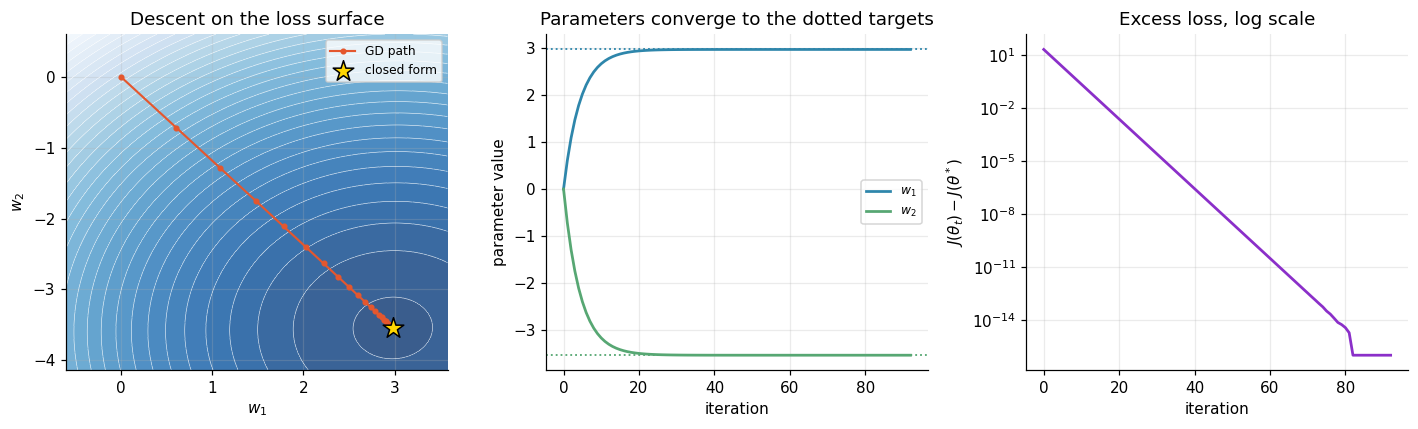

In [18]:
fig = plt.figure(figsize=(13, 4))

# --- loss surface with the optimisation path ---
pad = 0.6
w1 = np.linspace(min(traj[:, 0].min(), theta_star[0]) - pad, max(traj[:, 0].max(), theta_star[0]) + pad, 160)
w2 = np.linspace(min(traj[:, 1].min(), theta_star[1]) - pad, max(traj[:, 1].max(), theta_star[1]) + pad, 160)
W1, W2 = np.meshgrid(w1, w2)
grid = np.stack([W1.ravel(), W2.ravel()], axis=1)
Z = ((X @ grid.T - y[:, None]) ** 2).mean(axis=0).reshape(W1.shape)

ax1 = fig.add_subplot(1, 3, 1)
cs = ax1.contourf(W1, W2, Z, levels=30, cmap="Blues_r", alpha=0.8)
ax1.contour(W1, W2, Z, levels=30, colors="white", linewidths=0.4)
ax1.plot(traj[:, 0], traj[:, 1], "o-", color="#E4572E", ms=3, lw=1.4, label="GD path")
ax1.scatter(*theta_star, marker="*", s=200, color="gold", edgecolor="black", zorder=6, label="closed form")
ax1.set_xlabel("$w_1$")
ax1.set_ylabel("$w_2$")
ax1.set_title("Descent on the loss surface")
ax1.legend(fontsize=8)

# --- parameters over time ---
ax2 = fig.add_subplot(1, 3, 2)
for j in range(2):
    ax2.plot(traj[:, j], color=["#2E86AB", "#57A773"][j], lw=1.8, label=f"$w_{j+1}$")
    ax2.axhline(theta_star[j], color=["#2E86AB", "#57A773"][j], ls=":", lw=1.2)
ax2.set_xlabel("iteration")
ax2.set_ylabel("parameter value")
ax2.set_title("Parameters converge to the dotted targets")
ax2.legend(fontsize=8)

# --- loss over time ---
ax3 = fig.add_subplot(1, 3, 3)
losses = [mse_loss(t, X, y) for t in traj]
ax3.semilogy(np.array(losses) - mse_loss(theta_star, X, y) + 1e-16, color="#8B2FC9", lw=1.8)
ax3.set_xlabel("iteration")
ax3.set_ylabel("$J(\\theta_t) - J(\\theta^*)$")
ax3.set_title("Excess loss, log scale")

plt.tight_layout()
plt.show()

A deliberate choice in the third panel: it plots **excess loss**
$J(\theta_t) - J(\theta^\star)$ not raw loss.

Raw loss here bottoms out near 8.8, the irreducible noise floor, since the data
were generated with noise that no model can explain. Plotted raw, the curve
appears to flatten immediately and convergence looks finished long before it is.
Subtracting the floor exposes the geometric decay across its full range and makes the straight line on the log axis visible.

Whenever a loss curve looks like it "plateaus early", check whether we are
looking at the plateau of the method or the noise floor of the data.

---
---

# Part II · Many parameters and a budget

Part I ended with a working algorithm and a hidden cost. Look again at what one
iteration of batch gradient descent requires:

$$\nabla J(\theta) = \frac{2}{n} X^{\!\top}(X\theta - y)$$

Every one of the $n$ observations is touched and the reward is **a single
parameter update**. With $n = 2{,}000$ that is unremarkable. With $n = 10^8$ it is ruinous and it is ruinous twice over: the arithmetic is expensive and $X$ must fit in memory at once.

Worse, most of that work is redundant. The gradient is an average over the
dataset and averages converge fast. A random subsample of a few hundred points
usually gives a direction that is very nearly right.

That observation splits the design space in two and the split is the organizing
idea of this part.

## 2.1 · Two axes, not one ladder

The six methods below are usually presented as a single progression:
batch -> SGD -> mini-batch -> momentum -> RMSProp -> Adam with each rung superseding the last. That framing is memorable and it is wrong. It conflates two **independent** decisions:

| | | |
|---|---|---|
| **Axis 1: how much data per gradient estimate** | batch size | controls the **variance** of the gradient estimate and how many updates we extract from one pass over the data |
| **Axis 2: what to do with the gradient once we have it** | update rule | controls the **memory and conditioning** of the step |

Laid out as a grid rather than a ladder:

|                     | **plain** | **momentum** | **RMSProp** | **Adam** |
|---------------------|-----------|--------------|-------------|----------|
| **full batch** ($b=n$) | Batch GD | ✓ | ✓ | ✓ |
| **mini-batch** ($b=32$) | Mini-batch GD | Momentum | RMSProp | **Adam** |
| **single sample** ($b=1$) | SGD | ✓ | ✓ | ✓ |

Every cell is legal. The ✓ entries are perfectly sensible methods that simply
lack famous names. "Adam", as the term is used in practice, means *mini-batch
sampling plus the Adam update rule*, and the two choices are tuned separately.

This is not pedantry. It changes the code: batching logic and update logic are
independent so they belong in independent pieces. One training loop owns the
batching; four small classes own the step. Adding a seventh optimizer then means
writing one new class and modifying nothing that already works.

## 2.2 · One loop, four rules

Before any specific optimizer, the shared machinery and three deliberate
decisions inside it that determine whether the comparison at the end means
anything.

**Decision 1: one convergence criterion for every method.** It is tempting to
give each optimizer whatever stopping rule suits it: a loss-delta threshold here, a gradient-norm threshold there, a patience window somewhere else. Do that and the epoch counts we report at the end are not comparable because they are answers to different questions. Worse, a loss-delta rule cannot distinguish
*arrived* from *stalled*: an optimizer crawling across a plateau emits exactly
the same signal as one sitting at the optimum.

Here, every method stops on the same quantity: relative distance to the known
optimum, $\lVert w - w^\star \rVert / \lVert w^\star \rVert$. This is available
only because $w^\star$ is known in closed form which makes it a **diagnostic**
setup, not a template for real training. In real training, held-out loss is the
honest proxy.

**Decision 2: identical instrumentation.** Loss, distance to optimum, parameter
trajectory, update count and gradient-evaluation count are recorded the same way
for everything, at the same points in the loop.

**Decision 3: a named result object rather than a tuple.** Returning
`(weights, bias, history, losses, epoch)` forces every caller to unpack five
things in exactly the right order; get it wrong and we get no error, just wrong
plots. A small labelled container removes that whole class of bug.

In [19]:
@dataclass
class Result:
    """Everything one optimisation run produces, accessed by name."""
    weights: np.ndarray
    bias: float
    loss_history: list = field(default_factory=list)
    error_history: list = field(default_factory=list)
    trajectory: np.ndarray = None
    converged: bool = False
    epochs_to_target: int = None
    n_updates: int = 0
    n_gradient_evals: int = 0
    label: str = ""

    @property
    def final_error(self):
        return self.error_history[-1]

    @property
    def final_loss(self):
        return self.loss_history[-1]


# ---------------------------------------------------------------- update rules

class PlainUpdate:
    """theta <- theta - alpha * g.  The reference point for everything else."""
    name = "plain"
    def reset(self, d): pass
    def step(self, g_w, g_b, lr):
        return lr * g_w, lr * g_b


class MomentumUpdate:
    """Exponentially weighted average of past gradients."""
    name = "momentum"
    def __init__(self, beta=0.9):
        self.beta = beta
    def reset(self, d):
        self.v_w, self.v_b = np.zeros(d), 0.0
    def step(self, g_w, g_b, lr):
        self.v_w = self.beta * self.v_w + (1 - self.beta) * g_w
        self.v_b = self.beta * self.v_b + (1 - self.beta) * g_b
        return lr * self.v_w, lr * self.v_b


class RMSPropUpdate:
    """Per-parameter step size from a running average of squared gradients."""
    name = "rmsprop"
    def __init__(self, beta=0.9, eps=1e-8):
        self.beta, self.eps = beta, eps
    def reset(self, d):
        self.s_w, self.s_b = np.zeros(d), 0.0
    def step(self, g_w, g_b, lr):
        self.s_w = self.beta * self.s_w + (1 - self.beta) * g_w ** 2
        self.s_b = self.beta * self.s_b + (1 - self.beta) * g_b ** 2
        return (lr * g_w / (np.sqrt(self.s_w) + self.eps),
                lr * g_b / (np.sqrt(self.s_b) + self.eps))


class AdamUpdate:
    """First and second moments together, with bias correction."""
    name = "adam"
    def __init__(self, beta1=0.9, beta2=0.999, eps=1e-8):
        self.beta1, self.beta2, self.eps = beta1, beta2, eps
    def reset(self, d):
        self.t = 0
        self.m_w, self.v_w = np.zeros(d), np.zeros(d)
        self.m_b, self.v_b = 0.0, 0.0
    def step(self, g_w, g_b, lr):
        self.t += 1
        self.m_w = self.beta1 * self.m_w + (1 - self.beta1) * g_w
        self.m_b = self.beta1 * self.m_b + (1 - self.beta1) * g_b
        self.v_w = self.beta2 * self.v_w + (1 - self.beta2) * g_w ** 2
        self.v_b = self.beta2 * self.v_b + (1 - self.beta2) * g_b ** 2
        m_w_hat = self.m_w / (1 - self.beta1 ** self.t)
        m_b_hat = self.m_b / (1 - self.beta1 ** self.t)
        v_w_hat = self.v_w / (1 - self.beta2 ** self.t)
        v_b_hat = self.v_b / (1 - self.beta2 ** self.t)
        return (lr * m_w_hat / (np.sqrt(v_w_hat) + self.eps),
                lr * m_b_hat / (np.sqrt(v_b_hat) + self.eps))

In [20]:
def minimise(X, y, w_star, rule=None, batch_size=None, learning_rate=0.01,
             max_epochs=30, tol=1e-3, stop_at_tol=True, track=False,
             track_every=1, seed=0, label=""):
    """
    One training loop for every combination of batch size and update rule.

    batch_size:  None -> full batch,  1 -> stochastic,  b -> mini-batch.
    Convergence is measured as ||w - w*|| / ||w*||, identically for all methods.
    """
    rule = rule if rule is not None else PlainUpdate()
    rng = np.random.default_rng(seed)
    m, d = X.shape
    b_eff = m if batch_size is None else min(batch_size, m)

    w, bias = np.zeros(d), 0.0
    rule.reset(d)

    norm_star = np.linalg.norm(w_star)
    rel_err = lambda ww: float(np.linalg.norm(ww - w_star) / norm_star)
    loss_of = lambda ww, bb: float(np.mean((X @ ww + bb - y) ** 2))

    trajectory = [np.append(w, bias)] if track else None
    loss_history, error_history = [loss_of(w, bias)], [rel_err(w)]
    n_updates = n_grad_evals = 0
    converged, epochs_to_target = False, None

    for epoch in range(max_epochs):
        order = rng.permutation(m)
        Xs, ys = X[order], y[order]

        for i in range(0, m, b_eff):
            xb, yb = Xs[i:i + b_eff], ys[i:i + b_eff]
            nb = len(yb)

            residual = xb @ w + bias - yb
            g_w = (2 / nb) * (xb.T @ residual)
            g_b = (2 / nb) * float(np.sum(residual))

            step_w, step_b = rule.step(g_w, g_b, learning_rate)
            w, bias = w - step_w, bias - step_b

            n_updates += 1
            n_grad_evals += nb
            if track and n_updates % track_every == 0:
                trajectory.append(np.append(w, bias))

        epoch_loss = loss_of(w, bias)
        if not np.isfinite(epoch_loss):
            loss_history.append(np.inf); error_history.append(np.inf)
            break
        loss_history.append(epoch_loss)
        error_history.append(rel_err(w))

        if error_history[-1] < tol and not converged:
            converged, epochs_to_target = True, epoch + 1
            if stop_at_tol:
                break

    return Result(weights=w, bias=float(bias), loss_history=loss_history,
                  error_history=error_history,
                  trajectory=np.array(trajectory) if track else None,
                  converged=converged, epochs_to_target=epochs_to_target,
                  n_updates=n_updates, n_gradient_evals=n_grad_evals, label=label)


baseline = minimise(X, y, theta_star, batch_size=None, learning_rate=0.1,
                    max_epochs=200, tol=1e-6, label="Batch GD")
print(f"Batch GD: {baseline.epochs_to_target} epochs, "
      f"{baseline.n_updates} updates, "
      f"{baseline.n_gradient_evals:,} gradient evaluations")

Batch GD: 61 epochs, 61 updates, 122,000 gradient evaluations


## 2.3 · Stochastic gradient descent

Estimate the gradient from **one** randomly chosen observation:

$$\theta_{t+1} = \theta_t - \alpha \nabla J(\theta;\, x_i, y_i)$$

The estimate is unbiased, its expectation over a uniformly drawn $i$ is the true
gradient but its variance is large. The path zig-zags.

Two consequences follow and only one of them is usually stated.

**The stated one:** the noise can help escape shallow local minima and saddle
points. On a convex quadratic like ours there are none so we cannot demonstrate
this here and will not pretend to. Any claim about escaping local minima requires a non-convex test problem.

**The one that actually matters here:** SGD extracts $n$ updates from a single
pass over the data where batch GD extracts one. Both spend the same number of
per-sample gradient evaluations per epoch. The advantage is not cheaper
gradients, it is **more steps for the same data budget.**

The cost is that constant-step-size SGD does not converge to the optimum. It
converges to a *neighbourhood* whose radius is proportional to $\alpha$ and to
the gradient noise and then it mills around inside it forever. Shrinking $\alpha$ over time is what closes that gap.

In [21]:
res_bgd = minimise(X, y, theta_star, batch_size=None, learning_rate=0.1, max_epochs=40, tol=0, stop_at_tol=False, track=True, label="Batch GD")
res_sgd = minimise(X, y, theta_star, batch_size=1, learning_rate=0.01, max_epochs=40, tol=0, stop_at_tol=False, track=True, track_every=20, seed=0, label="SGD")

print(f"{'method':<12}{'updates':>10}{'grad evals':>14}{'final rel err':>16}")
print("-" * 52)
for r in (res_bgd, res_sgd):
    print(f"{r.label:<12}{r.n_updates:>10,}{r.n_gradient_evals:>14,}{r.final_error:>16.4e}")

print(f"\nSame data budget ({res_bgd.n_gradient_evals:,} gradient evaluations each),")
print(f"but SGD took {res_sgd.n_updates // res_bgd.n_updates}x as many parameter updates.")

method         updates    grad evals   final rel err
----------------------------------------------------
Batch GD            40        80,000      1.1286e-04
SGD             80,000        80,000      8.5544e-02

Same data budget (80,000 gradient evaluations each),
but SGD took 2000x as many parameter updates.


## 2.4 · Mini-batch: the compromise everyone actually uses

Neither extreme is right. Batch GD gives an exact direction and one step per
pass; SGD gives a noisy direction and $n$ steps per pass. Averaging over $b$
samples interpolates:

$$\theta_{t+1} = \theta_t - \frac{\alpha}{b}\sum_{i \in \mathcal{B}} \nabla J(\theta; x_i, y_i)$$

The variance of the mean of $b$ independent estimates falls as $1/b$, so the
**standard deviation** of the gradient estimate falls as $1/\sqrt{b}$. That
square root is the crux of the whole trade-off, and it is worth stating plainly:
going from $b=1$ to $b=100$ costs 100× the computation per update and buys only a
10× reduction in gradient noise. Diminishing returns set in fast, which is why
practical batch sizes cluster in the tens-to-hundreds rather than the thousands.

There is a second, subtler benefit: on modern hardware a batch of 32 is processed in roughly the time of a single sample, because the arithmetic is vectorized. So mini-batching is nearly free in wall-clock terms even where it is not free in FLOPs.

Let us verify the $1/\sqrt{b}$ law rather than assert it and watch it break in
an instructive way at the largest batch sizes.

In [22]:
rng_check = np.random.default_rng(1)
probe_theta = np.zeros(2)
n_total = len(y)

print("Gradient-noise scaling with batch size")
print(f"full-batch gradient: {mse_gradient(probe_theta, X, y).round(4)}   n = {n_total}\n")
print(f"{'batch b':>9}{'measured std':>15}{'sigma_1/sqrt(b)':>18}"
      f"{'x FPC':>12}{'corrected':>13}{'ratio':>9}")
print("-" * 78)

sigma_1 = None
for b in [1, 4, 16, 64, 256, 1024]:
    estimates = [mse_gradient(probe_theta, *(lambda i: (X[i], y[i]))(rng_check.choice(n_total, size=b, replace=False))) for _ in range(400)]
    measured = np.std(np.array(estimates), axis=0).mean()
    if sigma_1 is None:
        sigma_1 = measured

    naive = sigma_1 / np.sqrt(b)
    fpc = np.sqrt((n_total - b) / (n_total - 1))   # finite-population correction
    corrected = naive * fpc

    print(f"{b:>9}{measured:>15.4f}{naive:>18.4f}"
          f"{fpc:>12.4f}{corrected:>13.4f}{measured/corrected:>9.3f}")

Gradient-noise scaling with batch size
full-batch gradient: [-6.0744  7.1867]   n = 2000

  batch b   measured std   sigma_1/sqrt(b)       x FPC    corrected    ratio
------------------------------------------------------------------------------
        1        12.1506           12.1506      1.0000      12.1506    1.000
        4         6.5364            6.0753      0.9992       6.0707    1.077
       16         3.3132            3.0376      0.9962       3.0262    1.095
       64         1.5942            1.5188      0.9841       1.4947    1.067
      256         0.6869            0.7594      0.9340       0.7093    0.968
     1024         0.2697            0.3797      0.6987       0.2653    1.016


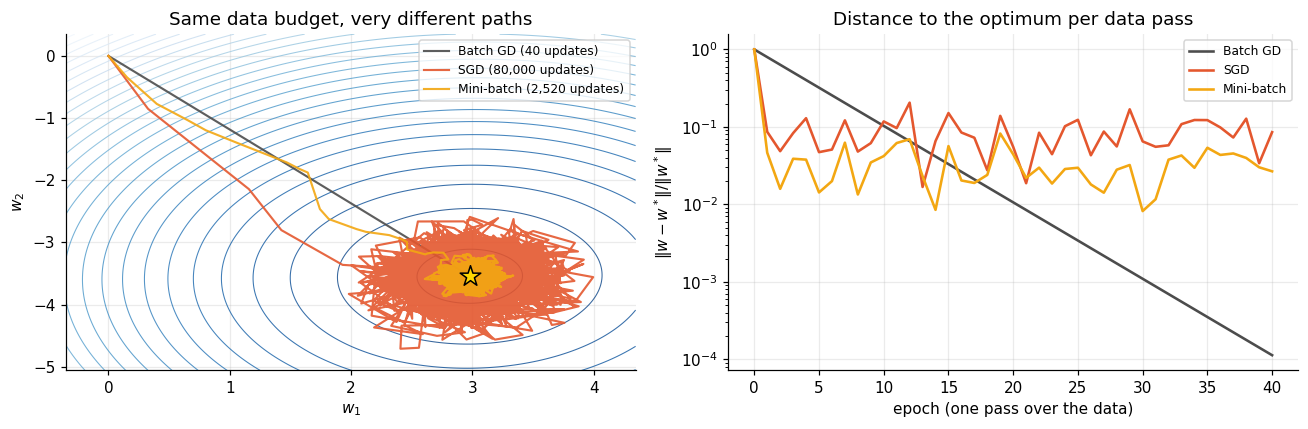

In [23]:
res_mbgd = minimise(X, y, theta_star, batch_size=32, learning_rate=0.05, max_epochs=40, tol=0, stop_at_tol=False, track=True, seed=0, label="Mini-batch")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pad = 0.35
allw = np.vstack([res_bgd.trajectory[:, :2], res_sgd.trajectory[:, :2], res_mbgd.trajectory[:, :2]])
w1 = np.linspace(allw[:, 0].min() - pad, allw[:, 0].max() + pad, 170)
w2 = np.linspace(allw[:, 1].min() - pad, allw[:, 1].max() + pad, 170)
W1, W2 = np.meshgrid(w1, w2)
grid = np.stack([W1.ravel(), W2.ravel()], axis=1)
Z = ((X @ grid.T - y[:, None]) ** 2).mean(axis=0).reshape(W1.shape)

axes[0].contour(W1, W2, Z, levels=28, cmap="Blues_r", linewidths=0.7, alpha=0.8)
for r in (res_bgd, res_sgd, res_mbgd):
    axes[0].plot(r.trajectory[:, 0], r.trajectory[:, 1], lw=1.4, alpha=0.9, color=PALETTE[r.label], label=f"{r.label} ({r.n_updates:,} updates)")
axes[0].scatter(*theta_star, marker="*", s=200, color="gold", edgecolor="black", zorder=6)
axes[0].set_xlabel("$w_1$")
axes[0].set_ylabel("$w_2$")
axes[0].set_title("Same data budget, very different paths")
axes[0].legend(fontsize=8)

for r in (res_bgd, res_sgd, res_mbgd):
    axes[1].semilogy(r.error_history, color=PALETTE[r.label], lw=1.7, label=r.label)
axes[1].set_xlabel("epoch (one pass over the data)")
axes[1].set_ylabel("$\\|w - w^*\\| / \\|w^*\\|$")
axes[1].set_title("Distance to the optimum per data pass")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Why the last two rows drift

The measured spread falls below the $1/\sqrt{b}$ prediction once $b$ becomes an
appreciable fraction of $n$. That is not a flaw in the law; it is a flaw in
applying the law without its assumption.

$1/\sqrt{b}$ holds for $b$ **independent** draws. We are sampling *without
replacement* from a finite dataset, so once the batch is a large share of the
population the draws are negatively correlated and in the limit $b = n$ the
"estimate" is the exact full-batch gradient with zero variance. The correction is the standard finite-population factor from survey sampling:

$$\sigma_b = \frac{\sigma_1}{\sqrt{b}}\sqrt{\frac{n-b}{n-1}}$$

The `corrected` column applies it and the `ratio` column shows measurement over
prediction: within 10% across three orders of magnitude of batch size, against a
naive prediction that was 41% too high at $b=1024$. At that batch size the factor is $\sqrt{976/1999} \approx 0.70$, and that 30% reduction is exactly the gap.

This matters in practice: the variance-reduction benefit of a very large batch is **smaller** than $1/\sqrt{b}$ suggests whenever the batch is a meaningful
fraction of our dataset, which is common on small problems.

### Back to the trajectories

The right panel shows the noise floor directly. Batch GD descends smoothly and
keeps descending. SGD drops much faster at first, it is taking 2,000 steps per
epoch instead of one and then flattens onto a horizontal band it never leaves.
That band *is* the neighbourhood of radius $O(\alpha)$; the method is converged in the only sense a constant step size permits.

Mini-batch sits between them which is the entire reason it is the default.

## 2.5 · Momentum

Look at the mini-batch path in the left panel: it makes progress along the valley while jittering across it. The jitter is not just cosmetic, it caps how large a step size we can use because $\alpha$ must be small enough to keep the
cross-valley oscillation stable even though the along-valley direction would
happily accept a much larger one.

Momentum attacks this by giving the update inertia. Instead of stepping along the current gradient, step along a running average of recent gradients:

$$v_t = \beta v_{t-1} + (1-\beta)\, \nabla J(\theta_t)
\qquad\qquad
\theta_{t+1} = \theta_t - \alpha\, v_t$$

**Why averaging helps is visible once the recurrence is unrolled.** Substituting
repeatedly and starting from $v_0 = 0$:

$$v_t = (1-\beta)\Big[\nabla J(\theta_t) + \beta \nabla J(\theta_{t-1})
+ \beta^2 \nabla J(\theta_{t-2}) + \dots + \beta^{t-1}\nabla J(\theta_1)\Big]$$

The weights $(1-\beta)\beta^k$ decay geometrically so this is an exponentially
weighted moving average with an effective window of about

$$\frac{1}{1-\beta} \;\text{ steps} \qquad (\beta = 0.9 \Rightarrow 10 \text{ steps})$$

Now the mechanism is obvious. In directions where the gradient keeps **flipping
sign**, the terms cancel and the average shrinks, the oscillation is damped. In
directions where the gradient **points consistently one way**, the terms
reinforce and the average grows toward the full gradient, progress accelerates.
One mechanism, two effects, both desirable.

**[verify by hand]** Under a constant gradient $g = 1$ with $\beta = 0.9$, the
recurrence gives $v_t = 1 - \beta^t$. At $t = 10$: $1 - 0.9^{10} = 1 - 0.3487 =
0.6513$. At $t = 22$: $1 - 0.9^{22} = 0.9015$ so it takes about 22 steps to
reach 90% of full speed, roughly twice the nominal window.

In [24]:
beta = 0.9
rule = MomentumUpdate(beta=beta)
rule.reset(1)
g = np.array([1.0])

print(f"Constant gradient g = 1,  beta = {beta},  effective window = {1/(1-beta):.0f} steps\n")
print(f"{'t':>4}{'velocity v_t':>16}{'1 - beta^t':>14}{'% of full speed':>18}")
print("-" * 52)
for t in range(1, 41):
    v = rule.step(g, 0.0, lr=1.0)[0][0]
    if t in (1, 2, 5, 10, 15, 20, 22, 30, 40):
        print(f"{t:>4}{v:>16.5f}{1 - beta**t:>14.5f}{100*v:>17.1f}%")

Constant gradient g = 1,  beta = 0.9,  effective window = 10 steps

   t    velocity v_t    1 - beta^t   % of full speed
----------------------------------------------------
   1         0.10000       0.10000             10.0%
   2         0.19000       0.19000             19.0%
   5         0.40951       0.40951             41.0%
  10         0.65132       0.65132             65.1%
  15         0.79411       0.79411             79.4%
  20         0.87842       0.87842             87.8%
  22         0.90152       0.90152             90.2%
  30         0.95761       0.95761             95.8%
  40         0.98522       0.98522             98.5%


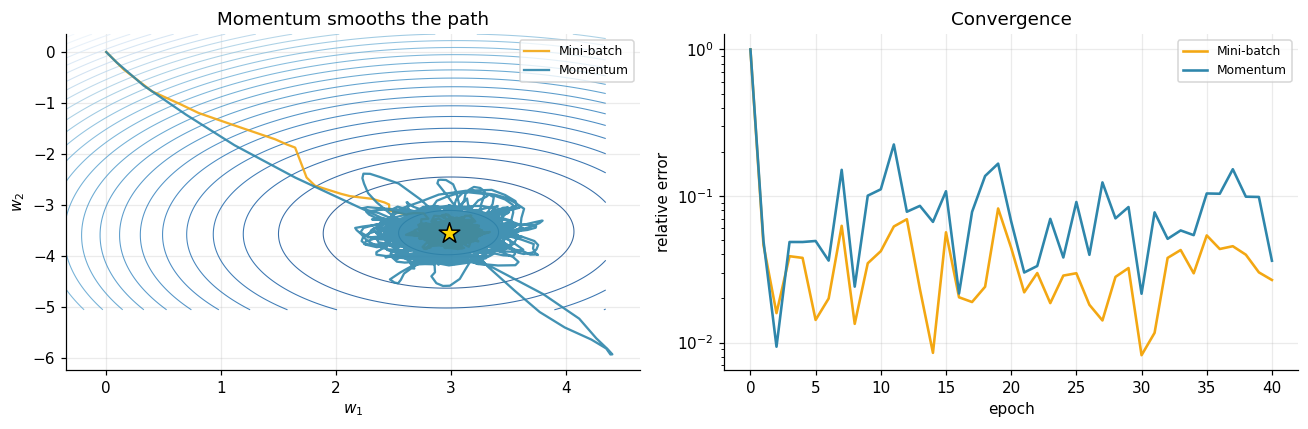

In [25]:
res_mom = minimise(X, y, theta_star, rule=MomentumUpdate(0.9), batch_size=32, learning_rate=0.3, max_epochs=40, tol=0, stop_at_tol=False, track=True, seed=0, label="Momentum")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].contour(W1, W2, Z, levels=28, cmap="Blues_r", linewidths=0.7, alpha=0.8)
for r in (res_mbgd, res_mom):
    axes[0].plot(r.trajectory[:, 0], r.trajectory[:, 1], lw=1.5, alpha=0.9, color=PALETTE[r.label], label=r.label)
axes[0].scatter(*theta_star, marker="*", s=200, color="gold", edgecolor="black", zorder=6)
axes[0].set_xlabel("$w_1$")
axes[0].set_ylabel("$w_2$")
axes[0].set_title("Momentum smooths the path")
axes[0].legend(fontsize=8)

for r in (res_mbgd, res_mom):
    axes[1].semilogy(r.error_history, color=PALETTE[r.label], lw=1.7, label=r.label)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("relative error")
axes[1].set_title("Convergence")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

One implementation warning because it causes a great deal of confusion when
comparing code across sources. Two conventions are in circulation:

$$\textbf{EWA form (used here): } v_t = \beta v_{t-1} + (1-\beta) g_t
\qquad\quad
\textbf{heavy-ball form: } v_t = \beta v_{t-1} + g_t$$

They differ by a factor of $(1-\beta)$ — a factor of **ten** at $\beta = 0.9$.
PyTorch's `SGD(momentum=...)` uses the heavy-ball form. Port a learning rate
between the two without rescaling and our model will appear to be broken and
the reason will not be obvious.

This is exactly why, in Part III, the learning rate is tuned separately for every method. A single shared learning rate across methods with different step-size conventions measures the conventions, not the algorithms.

## 2.6 · RMSProp

Momentum fixes *direction*. A different problem remains: **scale**.

One global $\alpha$ is applied to every parameter. If one parameter's gradients
are routinely of order $10^3$ and another's of order $10^{-3}$, no single $\alpha$ serves both: large enough to move the second is catastrophic for the first.

RMSProp gives every parameter its own effective step size derived from the
recent magnitude of *its own* gradients:

$$s_t = \beta s_{t-1} + (1-\beta) g_t^2
\qquad\qquad
\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{s_t} + \varepsilon}\, g_t$$

Squaring discards the sign so $s_t$ tracks magnitude only. The mechanism is
self-regulating: steep directions have large $s_t$ so dividing shrinks their
step; flat directions have small $s_t$ so dividing amplifies theirs.

**[verify by hand]** Under a constant gradient $g$, the running average
converges to $s \to g^2$ so the step becomes

$$\frac{\alpha}{\sqrt{g^2}}\, g = \alpha\,\operatorname{sign}(g)$$

exactly $\alpha$, **independent of the gradient's magnitude**. Feed it
gradients differing by six orders of magnitude and both parameters move at the
same rate. That scale invariance is the whole method.

The $\varepsilon \approx 10^{-8}$ prevents division by zero and quietly sets a
ceiling on how far a tiny gradient can be amplified.

In [26]:
rule = RMSPropUpdate(beta=0.9)
rule.reset(2)
g = np.array([1000.0, 0.001])           # six orders of magnitude apart
lr = 0.01

print(f"Constant gradients g = {g},  lr = {lr}\n")
print(f"{'step':>6}{'update to param 1':>22}{'update to param 2':>22}")
print("-" * 50)
for t in range(1, 501):
    step_w, _ = rule.step(g, 0.0, lr)
    if t in (1, 2, 5, 20, 100, 500):
        print(f"{t:>6}{step_w[0]:>22.6f}{step_w[1]:>22.6f}")

print(f"\nBoth converge to lr = {lr}. Plain GD would have moved them "
      f"{g[0]/g[1]:,.0f}x differently.")

Constant gradients g = [1.e+03 1.e-03],  lr = 0.01

  step     update to param 1     update to param 2
--------------------------------------------------
     1              0.031623              0.031622
     2              0.022942              0.022941
     5              0.015627              0.015626
    20              0.010670              0.010669
   100              0.010000              0.010000
   500              0.010000              0.010000

Both converge to lr = 0.01. Plain GD would have moved them 1,000,000x differently.


## 2.7 · Adam

Momentum and RMSProp fix orthogonal problems, direction and scale, so there is
no reason to choose. Adam (Kingma & Ba, 2015) tracks both:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t
\qquad\qquad
v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$

the first moment for direction ($\beta_1 = 0.9$, window ≈ 10 steps) and the
second for scale ($\beta_2 = 0.999$, window ≈ 1000 steps). The much longer window on $v$ is deliberate: a scale estimate should be stable while a direction estimate should be responsive.

### Bias correction, and the direction people get wrong

Both moments start at zero so both are biased toward zero early on. Adam
corrects:

$$\hat m_t = \frac{m_t}{1-\beta_1^{\,t}}
\qquad\qquad
\hat v_t = \frac{v_t}{1-\beta_2^{\,t}}
\qquad\qquad
\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{\hat v_t}+\varepsilon}\,\hat m_t$$

It is commonly said that without correction the opening steps would be *too
small* since both moments are underestimates. That is backwards and the
arithmetic is short enough to check.

**[verify by hand]** At $t = 1$ with a gradient $g$:

- $m_1 = (1-\beta_1) g = 0.1g$ — damped by $0.1$.
- $v_1 = (1-\beta_2) g^2 = 0.001g^2$, and it enters through a square root so
  $\sqrt{v_1} = 0.0316\,|g|$, damped by only $0.0316$.

The uncorrected step is therefore

$$\frac{0.1 g}{0.0316 |g|} = \frac{1-\beta_1}{\sqrt{1-\beta_2}} = 3.162$$

times **larger** than the corrected step which is exactly $\alpha$. The second
moment's underestimate dominates because dividing by an under-estimated
denominator inflates. **Bias correction is a brake on the opening steps, not an
accelerator** and its influence fades as $\beta_1^t, \beta_2^t \to 0$.

In [27]:
beta1, beta2 = 0.9, 0.999
g_val, lr = 5.0, 1.0

corrected = AdamUpdate(beta1, beta2)
corrected.reset(1)

m = v = 0.0
print(f"g = {g_val},  beta1 = {beta1},  beta2 = {beta2},  lr = {lr}\n")
print(f"{'t':>4}{'corrected step':>18}{'uncorrected step':>20}{'ratio':>10}")
print("-" * 54)
for t in range(1, 2001):
    c = corrected.step(np.array([g_val]), 0.0, lr)[0][0]
    m = beta1 * m + (1 - beta1) * g_val
    v = beta2 * v + (1 - beta2) * g_val ** 2
    u = lr * m / (np.sqrt(v) + 1e-8)
    if t in (1, 2, 5, 20, 100, 1000, 2000):
        print(f"{t:>4}{c:>18.5f}{u:>20.5f}{u/c:>10.3f}")

print(f"\npredicted ratio at t=1: (1-b1)/sqrt(1-b2) = "
      f"{(1-beta1)/np.sqrt(1-beta2):.3f}")

g = 5.0,  beta1 = 0.9,  beta2 = 0.999,  lr = 1.0

   t    corrected step    uncorrected step     ratio
------------------------------------------------------
   1           1.00000             3.16228     3.162
   2           1.00000             4.24959     4.250
   5           1.00000             5.79714     5.797
  20           1.00000             6.24093     6.241
 100           1.00000             3.24080     3.241
1000           1.00000             1.25758     1.258
2000           1.00000             1.07533     1.075

predicted ratio at t=1: (1-b1)/sqrt(1-b2) = 3.162


## 2.8 · All six on the standard test problem

Everything is built. Run all six on the standardized regression problem from
§1.6. The setup essentially every tutorial on this topic uses and compare.

One presentational discipline because it is easy to get wrong and consequential
when we do: each row below is generated programmatically from the result object
so a label can never drift away from the number beside it. Hand-written
`print` statements accumulated one method at a time are precisely how a
comparison table ends up reporting Adam's error under RMSProp's name.

In [28]:
SETUPS = {
    "Batch GD":   dict(rule=PlainUpdate,    batch_size=None, lr=0.10),
    "SGD":        dict(rule=PlainUpdate,    batch_size=1,    lr=0.005),
    "Mini-batch": dict(rule=PlainUpdate,    batch_size=32,   lr=0.05),
    "Momentum":   dict(rule=MomentumUpdate, batch_size=32,   lr=0.30),
    "RMSProp":    dict(rule=RMSPropUpdate,  batch_size=32,   lr=0.01),
    "Adam":       dict(rule=AdamUpdate,     batch_size=32,   lr=0.03),
}

runs, rows = {}, []
for name, cfg in SETUPS.items():
    r = minimise(X, y, theta_star, rule=cfg["rule"](), batch_size=cfg["batch_size"],
                 learning_rate=cfg["lr"], max_epochs=40, tol=1e-3,
                 stop_at_tol=False, track=True,
                 track_every=20 if cfg["batch_size"] == 1 else 1,
                 seed=0, label=name)
    runs[name] = r
    rows.append({
        "optimiser": name,
        "batch": cfg["batch_size"] or len(y),
        "lr": cfg["lr"],
        "updates": r.n_updates,
        "grad evals": r.n_gradient_evals,
        "epochs to 0.1%": r.epochs_to_target if r.converged else None,
        "final rel err": r.final_error,
        "final MSE": r.final_loss,
    })

summary = pd.DataFrame(rows).set_index("optimiser")
print("All six, equal budget of 40 data passes, standardised features\n")
print(summary.to_string(float_format=lambda v: f"{v:,.5g}"))
print(f"\nclosed-form optimum w* = {theta_star.round(5)}   MSE = {mse_loss(theta_star, X, y):.5f}")

All six, equal budget of 40 data passes, standardised features

            batch    lr  updates  grad evals  epochs to 0.1%  final rel err  final MSE
optimiser                                                                             
Batch GD     2000   0.1       40       80000              31     0.00011286     8.8107
SGD             1 0.005    80000       80000             NaN       0.059816     8.8917
Mini-batch     32  0.05     2520       80000             NaN        0.02671     8.8266
Momentum       32   0.3     2520       80000             NaN       0.036145     8.8402
RMSProp        32  0.01     2520       80000              40     0.00099616     8.8109
Adam           32  0.03     2520       80000             NaN      0.0025717     8.8109

closed-form optimum w* = [ 2.9781  -3.54368]   MSE = 8.81073


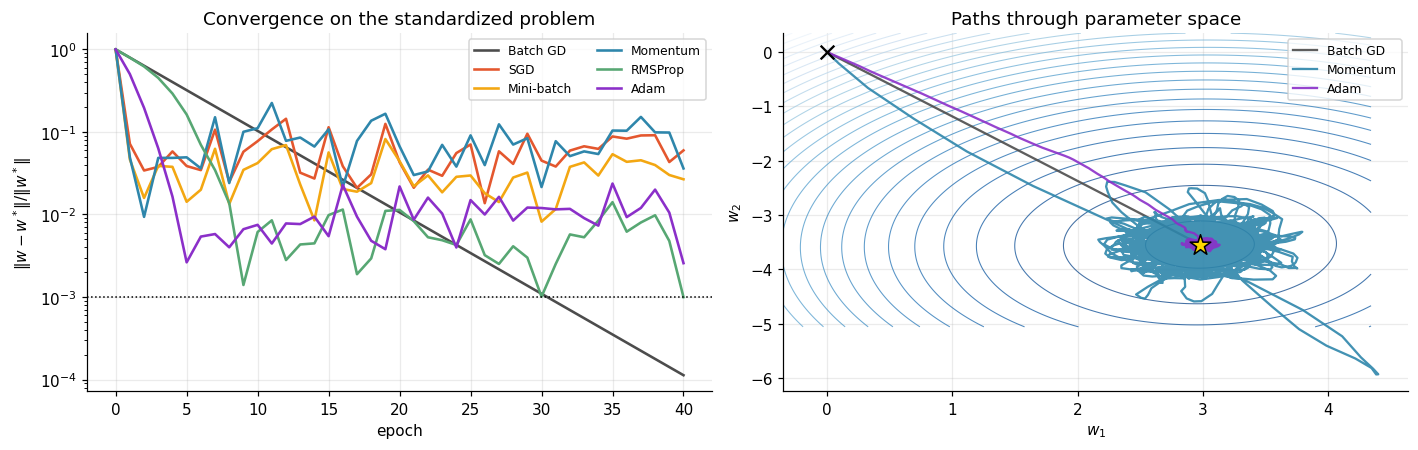

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for name, r in runs.items():
    axes[0].semilogy(r.error_history, color=PALETTE[name], lw=1.7, label=name)
axes[0].axhline(1e-3, color="black", ls=":", lw=1)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("$\\|w-w^*\\|/\\|w^*\\|$")
axes[0].set_title("Convergence on the standardized problem")
axes[0].legend(fontsize=8, ncol=2)

axes[1].contour(W1, W2, Z, levels=28, cmap="Blues_r", linewidths=0.7, alpha=0.75)
for name in ["Batch GD", "Momentum", "Adam"]:
    t = runs[name].trajectory
    axes[1].plot(t[:, 0], t[:, 1], lw=1.5, alpha=0.9, color=PALETTE[name], label=name)
axes[1].scatter(*theta_star, marker="*", s=200, color="gold", edgecolor="black", zorder=6)
axes[1].scatter(0, 0, marker="x", s=80, color="black", zorder=6)
axes[1].set_xlabel("$w_1$")
axes[1].set_ylabel("$w_2$")
axes[1].set_title("Paths through parameter space")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Every method lands on essentially the same coefficients and every final MSE sits
within a hair of the closed-form optimum. So far, so unremarkable.

But look again at the `final rel err` column and notice something that the
six-rung-ladder story does not predict at all: **plain batch gradient descent is
the most accurate method in the table.** Not Adam. The oldest and simplest
algorithm here, the one Part II opened by declaring unscalable, is closest to the optimum.

It is tempting to explain that away as a learning-rate accident. It is not. It is a symptom, and Part III diagnoses it. Two things are wrong with the experiment just performed, and neither is a coding error, both are design flaws that this notebook shares with essentially every treatment of the subject.

---
---

# Part III · Testing the conclusion

## 3.1 · What is wrong with the comparison we just ran

### Flaw 1: the learning rates were chosen, not tuned

Look back at `SETUPS`. Batch GD got 0.10, SGD got 0.005, Momentum got 0.30, Adam
got 0.03. Where did those come from? They were picked to make each method behave
reasonably. That is not tuning; it is curation and a comparison built on it
measures *how well the author guessed* for each method.

The problem is unavoidable rather than sloppy, because the update rules do not
share a step-size convention:

- Momentum's $(1-\beta)$ factor shrinks its effective step by ~10x at $\beta=0.9$.
- Adam's step is normalized to roughly $\alpha$ regardless of gradient magnitude.
- Plain GD's step scales directly with the gradient.

A single shared learning rate across these would be *unfair by construction*. The only defensible protocol is to give each method the same grid and let each keep its own best.

### Flaw 2" and this is the serious one -> the test problem cannot separate them

We standardized the features. Every tutorial does and it is unremarked boilerplate. Let us look at what it did to the geometry.

For the quadratic loss $J(w) = \frac1n\lVert Xw - y\rVert^2$, the curvature is
fully described by the Hessian, which is **constant**:

$$H = \nabla^2 J = \frac{2}{n} X^{\!\top}X$$

Its eigenvalues are the curvatures along the principal axes of the loss bowl, and the number that governs first-order optimization is their ratio, the **condition number**:

$$\kappa = \frac{\lambda_{\max}}{\lambda_{\min}}$$

The classical result for gradient descent on a quadratic with the optimal step
size is that the error contracts by

$$\left(\frac{\kappa-1}{\kappa+1}\right) \text{ per iteration.}$$

At $\kappa = 1$ that factor is **zero**, convergence in a single step. As
$\kappa \to \infty$ it approaches 1 and progress stops.

In [31]:
H = (2 / len(y)) * (X.T @ X)
eigenvalues = np.linalg.eigvalsh(H)
kappa = eigenvalues.max() / eigenvalues.min()

print("Hessian of our standardised problem:")
print(H.round(4))
print(f"\neigenvalues        : {eigenvalues.round(4)}")
print(f"condition number   : kappa = {kappa:.4f}")
print(f"predicted contraction per step: (k-1)/(k+1) = {(kappa-1)/(kappa+1):.6f}")
print(f"optimal step size  : 2/(lmax+lmin) = {2/(eigenvalues.sum()):.6f}")
print(f"stability limit    : alpha < 2/lmax = {2/eigenvalues.max():.6f}")

Hessian of our standardised problem:
[[ 2.     -0.0334]
 [-0.0334  2.    ]]

eigenvalues        : [1.9666 2.0334]
condition number   : kappa = 1.0339
predicted contraction per step: (k-1)/(k+1) = 0.016679
optimal step size  : 2/(lmax+lmin) = 0.500000
stability limit    : alpha < 2/lmax = 0.983594


$\kappa \approx 1$. The loss surface is a nearly perfect circular bowl.

This is not an accident of our data, it is what standardization *does*. Scaling
every feature to unit variance sets the diagonal of $\frac1n X^\top X$ to 1 and
with independent features the off-diagonals are near zero so $H \approx 2I$.

And at $\kappa \approx 1$, **there is nothing for a better optimizer to
improve.** Momentum has no oscillation to damp. RMSProp has no scale disparity to rescale. Adam has neither. The differences in the §2.8 table are differences in effective step size, not in algorithmic quality.

Stated plainly: **the standard demonstration deletes the exact pathology that
motivated inventing momentum and RMSProp.**

Let us confirm the theory predicts reality before building on it.

In [32]:
alpha_opt = 2 / eigenvalues.sum()
verify = minimise(X, y, theta_star, batch_size=None, learning_rate=alpha_opt,
                  max_epochs=30, tol=0, stop_at_tol=False)

errors = np.array(verify.error_history)
measured = errors[1:6] / errors[0:5]          # consecutive error ratios

print(f"predicted contraction (k-1)/(k+1) : {(kappa-1)/(kappa+1):.6f}")
print(f"measured ratios over 5 iterations : {measured.round(6)}")
print(f"mean measured                     : {measured.mean():.6f}")
print("\nTheory and measurement agree, so the condition number really does")
print("govern the convergence rate. That gives us a knob to turn.")

predicted contraction (k-1)/(k+1) : 0.016679
measured ratios over 5 iterations : [0.016679 0.016679 0.016679 0.016679 0.016679]
mean measured                     : 0.016679

Theory and measurement agree, so the condition number really does
govern the convergence rate. That gives us a knob to turn.


## 3.2 · Three loss surfaces built on purpose

If $\kappa$ governs everything, we should vary it deliberately instead of
accidentally setting it to 1. But $\kappa$ alone is not enough because there are
two *geometrically different* ways for a surface to be ill-conditioned and the
adaptive methods respond to them differently.

RMSProp and Adam keep **one scalar per parameter**. They can stretch and shrink
the coordinate axes; they cannot rotate them. In linear-algebra terms they are
**diagonal preconditioners**. So:

| regime | how it is built | $\kappa$ | curvature is… | diagonal fix possible? |
|---|---|---|---|---|
| **isotropic** | independent features, standardized | ≈ 1 | absent | nothing to fix |
| **anisotropic** | features left on scales differing 30x | large | severe, **axis-aligned** | **yes** |
| **correlated** | standardized features, $\rho = 0.95$ | large | severe, **rotated** | **no** |

This yields a falsifiable prediction, stated before we run anything:

> RMSProp and Adam should dominate the anisotropic regime and lose most of their
> advantage in the correlated one even though both are ill-conditioned.

Note what the anisotropic regime requires: we must **not** standardize. Doing so
would erase the condition being studied which is precisely the mistake diagnosed
in §3.1.

In [33]:
def make_problem(regime, n_samples=1000, noise_std=3.0, beta=(3.0, -0.7), rho=0.95, scale_ratio=30.0, seed=0):
    """
    A regression problem with a prescribed loss-surface geometry.

    Returns X, y, the analytical optimum, and the condition number of the
    Hessian. The target is always centred so the optimal bias is zero.
    """
    rng = np.random.default_rng(seed)
    beta = np.asarray(beta, dtype=float)

    if regime == "correlated":
        cov = np.array([[1.0, rho], [rho, 1.0]])
        X_raw = rng.multivariate_normal(np.zeros(2), cov, size=n_samples)
    elif regime == "anisotropic":
        X_raw = np.column_stack([rng.normal(0, 1.0, n_samples), rng.normal(0, scale_ratio, n_samples)])
    elif regime == "isotropic":
        X_raw = rng.normal(0, 1.0, (n_samples, 2))
    else:
        raise ValueError(regime)

    y_raw = X_raw @ beta + rng.normal(0, noise_std, n_samples)

    # Standardize everywhere EXCEPT the anisotropic case, where the scale
    # disparity is the experimental condition.
    Xp = X_raw if regime == "anisotropic" else (X_raw - X_raw.mean(0)) / X_raw.std(0)
    yp = y_raw - y_raw.mean()

    w_opt, *_ = np.linalg.lstsq(Xp, yp, rcond=None)
    Hm = (2 / n_samples) * (Xp.T @ Xp)
    ev = np.linalg.eigvalsh(Hm)
    return Xp, yp, w_opt, float(ev.max() / ev.min())


REGIMES = ["isotropic", "anisotropic", "correlated"]
for reg in REGIMES:
    Xr, yr, wr, kr = make_problem(reg, seed=0)
    print(f"{reg:<13} kappa = {kr:>10,.1f}    w* = {wr.round(3)}")

isotropic     kappa =        1.0    w* = [ 2.948 -0.739]
anisotropic   kappa =      987.8    w* = [ 2.843 -0.699]
correlated    kappa =       42.1    w* = [ 3.273 -0.833]


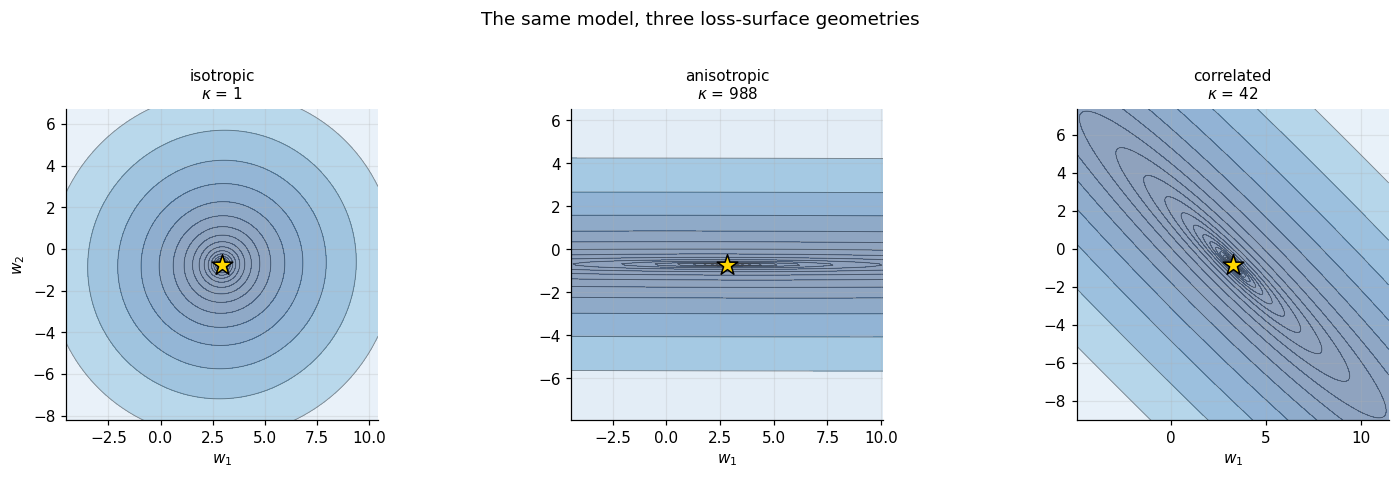

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

for ax, reg in zip(axes, REGIMES):
    Xr, yr, wr, kr = make_problem(reg, seed=0)
    span = 2.2 * np.abs(wr).max() + 1
    g1 = np.linspace(wr[0] - span, wr[0] + span, 200)
    g2 = np.linspace(wr[1] - span, wr[1] + span, 200)
    G1, G2 = np.meshgrid(g1, g2)
    pts = np.stack([G1.ravel(), G2.ravel()], axis=1)
    Zr = ((Xr @ pts.T - yr[:, None]) ** 2).mean(axis=0).reshape(G1.shape)

    excess = Zr - Zr.min()
    levels = Zr.min() + np.geomspace(1e-3, max(excess.max(), 1e-2), 24)
    ax.contourf(G1, G2, Zr, levels=levels, cmap="Blues_r", alpha=0.45, extend="both")
    ax.contour(G1, G2, Zr, levels=levels, colors="#444", linewidths=0.6, alpha=0.55)
    ax.scatter(*wr, marker="*", s=200, color="gold", edgecolor="black", zorder=6)
    ax.set_title(f"{reg}\n$\\kappa$ = {kr:,.0f}", fontsize=10)
    ax.set_xlabel("$w_1$")
    ax.set_aspect("equal", adjustable="box")

axes[0].set_ylabel("$w_2$")
fig.suptitle("The same model, three loss-surface geometries", y=1.02)
plt.tight_layout()
plt.show()

The three pictures are the experiment in miniature.

**Isotropic:** circular contours. The negative gradient points straight at the
star from anywhere.

**Anisotropic:** an extremely narrow valley whose axis is **aligned with the
coordinate axes**. Rescaling $w_2$ alone would turn this back into a circle,
exactly what a diagonal preconditioner does.

**Correlated:** an equally narrow valley but lying **diagonally**. No amount of
independent rescaling of $w_1$ and $w_2$ can straighten a diagonal valley; that
requires a rotation, which diagonal methods cannot express.

## 3.3 · The protocol

Five commitments, each fixing a specific way this comparison could mislead.

1. **Equal data budget.** Every method gets the same number of passes. This
   equalizes gradient evaluations exactly, whatever the batch size, one epoch
   touches every sample once. It does *not* equalize parameter updates and that
   asymmetry is reported rather than hidden.

2. **Per-method learning-rate tuning** over a shared grid, selected on a **tuning seed disjoint from the evaluation seeds** so the reported numbers are not fitted to the data they are reported on.

3. **Fixed-budget error as the headline metric**, $\lVert w - w^\star\rVert /
   \lVert w^\star\rVert$ after the budget is spent. Unlike "epochs to
   convergence" it is always defined so a method that never reaches a threshold
   still produces a comparable number rather than a blank.

4. **Multiple seeds, reported as a median**, with a hit rate alongside so a
   method that succeeds on one seed in three cannot hide behind a lucky median.

5. **One stopping rule for everything**, shared across methods and regimes.

In [35]:
import warnings

LR_GRID = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0]
TARGET, BUDGET = 1e-2, 25
EVAL_SEEDS = [0, 1, 2, 3, 4]
TUNE_SEEDS = [9000, 9001, 9002]        # disjoint from the evaluation seeds
N = 1000

# At the top of the grid some methods diverge to overflow. That is the correct
# behaviour -- a learning rate above the stability limit 2/lambda_max MUST blow
# up -- and the tuner discards those runs. Silencing the warning keeps the
# output readable; it is not hiding a bug.

warnings.filterwarnings("ignore", category=RuntimeWarning)

def run_one(regime, cfg, lr, seed):
    Xr, yr, wr, _ = make_problem(regime, n_samples=N, seed=seed)
    return minimise(Xr, yr, wr, rule=cfg["rule"](), batch_size=cfg["batch_size"], learning_rate=lr, max_epochs=BUDGET, tol=TARGET, stop_at_tol=False, seed=seed)

records = []
for regime in REGIMES:
    _, _, _, kr = make_problem(regime, n_samples=N, seed=0)
    print(f"--- {regime} (kappa = {kr:,.0f}) ---")
    for name, cfg in SETUPS.items():
        # Tune on the MEAN error across several held-out seeds. Tuning on a
        # single seed selects a step size that suits one particular draw and
        # generalises poorly -- the tuner itself overfits.
        best_lr, best_err = np.nan, np.inf
        for lr in LR_GRID:
            errs = [run_one(regime, cfg, lr, ts).final_error for ts in TUNE_SEEDS]
            e = np.mean(errs) if all(np.isfinite(errs)) else np.inf
            if np.isfinite(e) and e < best_err:
                best_err, best_lr = e, lr
        # evaluate on disjoint seeds
        runs_ = [run_one(regime, cfg, best_lr, s) for s in EVAL_SEEDS]
        for s, r in zip(EVAL_SEEDS, runs_):
            records.append({"regime": regime, "kappa": kr, "optimiser": name,
                            "lr": best_lr, "seed": s,
                            "rel_error": r.final_error, "mse": r.final_loss,
                            "hit": r.converged,
                            "epochs_to_target": r.epochs_to_target,
                            "updates": r.n_updates})
        med = np.median([r.final_error for r in runs_])
        hits = sum(r.converged for r in runs_)
        print(f"   {name:<12} lr={best_lr:<7} rel.err={med:8.2e}  "
              f"reached {TARGET:g} in {hits}/{len(EVAL_SEEDS)} seeds")

raw = pd.DataFrame(records)
print("\ndone.")

--- isotropic (kappa = 1) ---
   Batch GD     lr=0.3     rel.err=1.30e-10  reached 0.01 in 5/5 seeds
   SGD          lr=0.0003  rel.err=4.28e-03  reached 0.01 in 5/5 seeds
   Mini-batch   lr=0.003   rel.err=4.90e-03  reached 0.01 in 3/5 seeds
   Momentum     lr=0.01    rel.err=5.17e-03  reached 0.01 in 5/5 seeds
   RMSProp      lr=0.01    rel.err=9.10e-03  reached 0.01 in 5/5 seeds
   Adam         lr=0.01    rel.err=7.17e-03  reached 0.01 in 4/5 seeds
--- anisotropic (kappa = 988) ---
   Batch GD     lr=0.001   rel.err=9.26e-01  reached 0.01 in 0/5 seeds
   SGD          lr=0.0001  rel.err=9.86e-03  reached 0.01 in 3/5 seeds
   Mini-batch   lr=0.001   rel.err=1.96e-01  reached 0.01 in 0/5 seeds
   Momentum     lr=0.003   rel.err=1.22e-02  reached 0.01 in 3/5 seeds
   RMSProp      lr=0.01    rel.err=7.02e-03  reached 0.01 in 5/5 seeds
   Adam         lr=0.03    rel.err=7.53e-03  reached 0.01 in 5/5 seeds
--- correlated (kappa = 42) ---
   Batch GD     lr=0.3     rel.err=3.96e-01  reached

In [36]:
summary3 = (raw.groupby(["regime", "optimiser"], sort=False).agg(kappa=("kappa", "median"), lr=("lr", "first"),
                   rel_error=("rel_error", "median"), mse=("mse", "median"),
                   hit_rate=("hit", "mean"),
                   epochs=("epochs_to_target", "median"),
                   updates=("updates", "median")).reset_index())

summary3["hit_rate"] = (summary3["hit_rate"] * 100).round(0).astype(int)

for reg in REGIMES:
    block = summary3[summary3.regime == reg].drop(columns=["regime", "kappa"])
    best = block.loc[block.rel_error.idxmin(), "optimiser"]
    print(f"\n=== {reg.upper()}  (kappa = {summary3[summary3.regime==reg].kappa.iloc[0]:,.0f}) "
          f"  best: {best} ===")
    print(block.to_string(index=False, float_format=lambda v: f"{v:,.4g}"))


=== ISOTROPIC  (kappa = 1)   best: Batch GD ===
 optimiser     lr  rel_error   mse  hit_rate  epochs  updates
  Batch GD    0.3  1.298e-10 8.858       100       6       25
       SGD 0.0003    0.00428 8.859       100       8  2.5e+04
Mini-batch  0.003   0.004901  8.86        60      22      800
  Momentum   0.01   0.005171 8.858       100       6      800
   RMSProp   0.01   0.009101 8.859       100      14      800
      Adam   0.01   0.007173 8.859        80    23.5      800

=== ANISOTROPIC  (kappa = 988)   best: RMSProp ===
 optimiser     lr  rel_error   mse  hit_rate  epochs  updates
  Batch GD  0.001     0.9256 17.44         0     NaN       25
       SGD 0.0001   0.009858  8.96        60      25  2.5e+04
Mini-batch  0.001      0.196 11.45         0     NaN      800
  Momentum  0.003    0.01217  9.13        60      22      800
   RMSProp   0.01   0.007017 8.972       100      15      800
      Adam   0.03   0.007532 8.828       100       8      800

=== CORRELATED  (kappa = 42)  

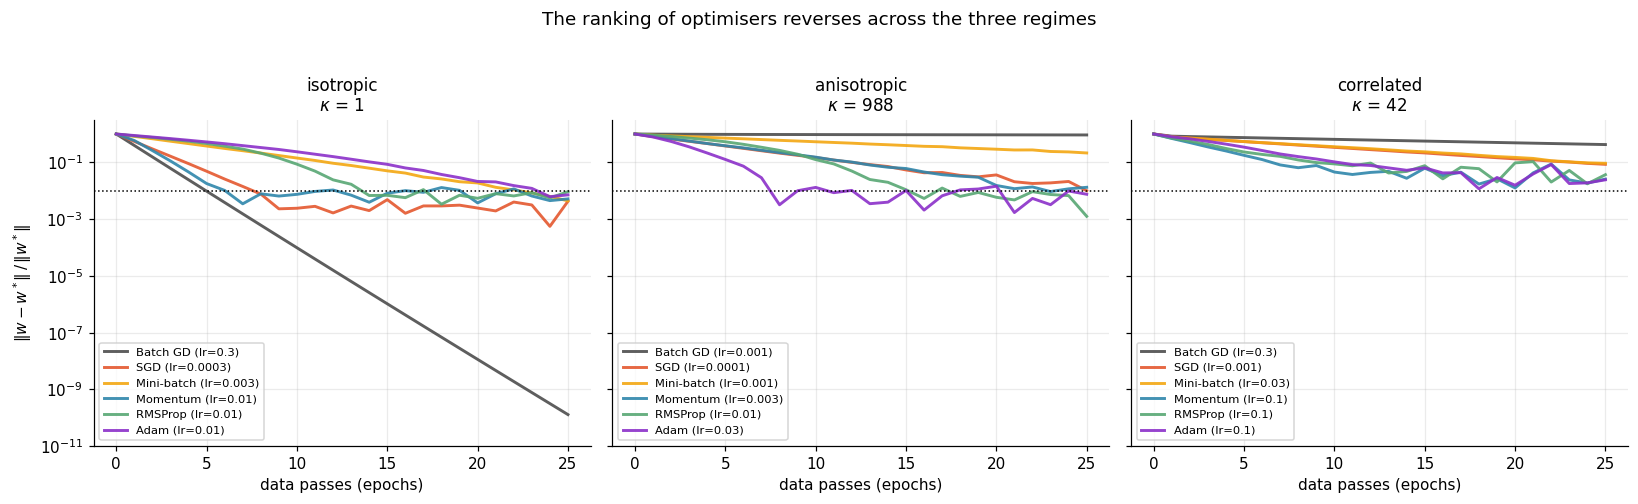

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)

for ax, regime in zip(axes, REGIMES):
    Xr, yr, wr, kr = make_problem(regime, n_samples=N, seed=0)
    for name, cfg in SETUPS.items():
        lr = summary3[(summary3.regime == regime) & (summary3.optimiser == name)].lr.iloc[0]
        r = minimise(Xr, yr, wr, rule=cfg["rule"](), batch_size=cfg["batch_size"], learning_rate=lr, max_epochs=BUDGET, tol=TARGET, stop_at_tol=False, seed=0)
        ax.semilogy(np.clip(r.error_history, 1e-12, None), color=PALETTE[name], lw=1.9, alpha=0.9, label=f"{name} (lr={lr:g})")
    ax.axhline(TARGET, color="black", ls=":", lw=1)
    ax.set_title(f"{regime}\n$\\kappa$ = {kr:,.0f}", fontsize=11)
    ax.set_xlabel("data passes (epochs)")
    ax.legend(fontsize=7.5)

axes[0].set_ylabel("$\\|w - w^*\\| \\, / \\, \\|w^*\\|$")
axes[0].set_ylim(1e-11, 3)
fig.suptitle("The ranking of optimisers reverses across the three regimes", y=1.03)
plt.tight_layout()
plt.show()

## 3.4 · What the three panels say

### Isotropic: plain batch gradient descent wins by orders of magnitude

The simplest method beats Adam decisively. This is not an anomaly; it is what
§3.1 predicts. At $\kappa \approx 1$ the exact gradient points essentially at the optimum and batch GD is the only method here that computes the exact gradient. Every other method is paying for stochasticity it does not need and the adaptive machinery has nothing to adapt to.

**On the standard test problem, the one in Part II, and in most tutorials: the
sophistication of Adam buys nothing at all.**

### Anisotropic: the ranking inverts

Batch GD, the previous winner barely moves. The reason is §1.5 in many
dimensions: stability requires $\alpha < 2/\lambda_{\max}$, so the steep direction dictates a step size hundreds of times too small for the flat one. It is stable and it is stuck.

RMSProp and Adam reach the target on every seed. This is the regime they were
invented for and the effect is not subtle.

### Correlated: the adaptive advantage collapses

Here is the payoff for separating axis-aligned from rotated curvature and the
prediction made in §3.2 before any of this was run.

The condition number in this panel is roughly **23x smaller** than in the
anisotropic one, a far easier problem by that measure and yet every method
does an order of magnitude worse and nobody reliably reaches the 1% target.

Quantify the collapse. In the anisotropic regime RMSProp reached
$7.0\times10^{-3}$ against mini-batch's $1.96\times10^{-1}$ — a **28-fold**
advantage. Here it reaches $5.6\times10^{-2}$ against mini-batch's
$9.3\times10^{-2}$: **under 2-fold**, on a problem with a twenty-third of the
conditioning to fix.

Note also which method has the best hit rate: **momentum**, at 60%, ahead of both adaptive methods. Momentum averages gradient *vectors* so it retains directional information across the rotated axes; RMSProp and Adam average squared components per coordinate which discards precisely the cross-coordinate structure this surface consists of.

Diagonal preconditioning cannot fix a rotation. Straightening this valley
requires off-diagonal curvature information that none of these methods carries
which is exactly what second-order and non-diagonal methods (L-BFGS, K-FAC,
Shampoo) exist to supply and why their absence is the largest gap in this
experimental design.

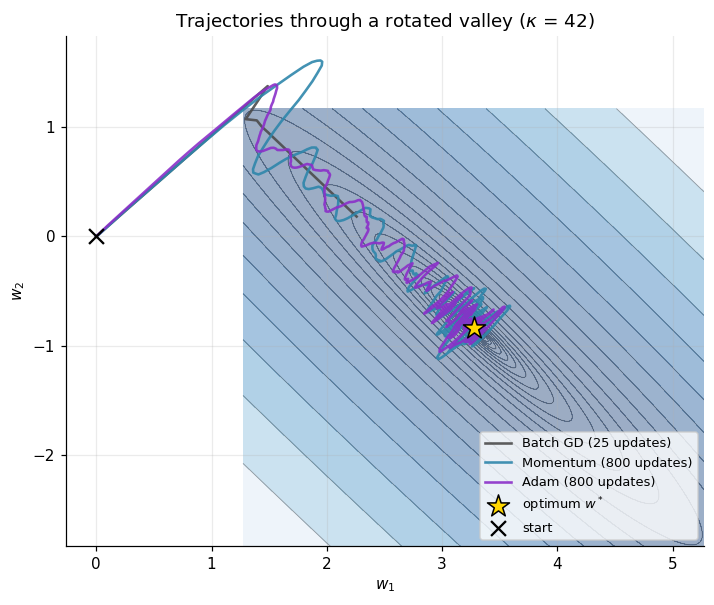

In [39]:
Xc, yc, wc, kc = make_problem("correlated", n_samples=N, seed=0)

span = 2.0
g1 = np.linspace(wc[0] - span, wc[0] + span, 240)
g2 = np.linspace(wc[1] - span, wc[1] + span, 240)
G1, G2 = np.meshgrid(g1, g2)
pts = np.stack([G1.ravel(), G2.ravel()], axis=1)
Zc = ((Xc @ pts.T - yc[:, None]) ** 2).mean(axis=0).reshape(G1.shape)
excess = Zc - Zc.min()
levels = Zc.min() + np.geomspace(1e-3, max(excess.max(), 1e-2), 24)

fig, ax = plt.subplots(figsize=(6.6, 5.6))
ax.contourf(G1, G2, Zc, levels=levels, cmap="Blues_r", alpha=0.4, extend="both")
ax.contour(G1, G2, Zc, levels=levels, colors="#444", alpha=0.45, linewidths=0.6)

for name in ["Batch GD", "Momentum", "Adam"]:
    cfg = SETUPS[name]
    lr = summary3[(summary3.regime == "correlated") & (summary3.optimiser == name)].lr.iloc[0]
    r = minimise(Xc, yc, wc, rule=cfg["rule"](), batch_size=cfg["batch_size"], learning_rate=lr, max_epochs=BUDGET, tol=TARGET, stop_at_tol=False, track=True, seed=0)
    ax.plot(r.trajectory[:, 0], r.trajectory[:, 1], lw=1.7, alpha=0.9, color=PALETTE[name], label=f"{name} ({r.n_updates} updates)")

ax.scatter(*wc, marker="*", s=230, color="gold", edgecolor="black", zorder=6, label="optimum $w^*$")
ax.scatter(0, 0, marker="x", s=95, color="black", zorder=6, label="start")
ax.set_xlabel("$w_1$")
ax.set_ylabel("$w_2$")
ax.set_title(f"Trajectories through a rotated valley ($\\kappa$ = {kc:,.0f})")
ax.legend(fontsize=8.5, loc="lower right")
plt.tight_layout()
plt.show()

## 3.5 · What this changes

**1. "Adam is the best optimizer" is not a claim that can be evaluated without
specifying the loss surface.** Across three regimes differing only in how the
features were generated, each of batch GD, RMSProp and Adam is optimal somewhere
and beaten decisively somewhere else.

**2. Adaptive methods repair axis-aligned curvature, not curvature in general.**
This follows from their diagonal state and is measured directly: RMSProp's
advantage over plain mini-batch falls from 28x to under 2x when the same amount
of ill-conditioning is *rotated* rather than axis-aligned even though the
rotated problem has a condition number 23x smaller. What changed was the
orientation of the curvature and not its severity.

**3. Feature preprocessing and optimizer choice are the same decision.**
Standardization moves a problem from the anisotropic regime to the isotropic one
and thereby makes the adaptive methods redundant. A pipeline that standardizes
and then reaches for Adam is paying twice for one fix. Conversely, adaptive
methods earn their keep exactly where standardization is impossible: embeddings,
attention weights, anything whose scale is learned rather than given.

**4. A comparison that reports epochs under per-method stopping rules measures
the stopping rules.** This is easy to do by accident and produces confident,
meaningless rankings.

**5. The demonstration problem is part of the claim.** Any statement of the form
"method A beats method B" is incomplete without the geometry it was measured on.

---
---

# Part IV · Limitations

**The loss is quadratic and convex.** No local minima, no saddle points, no
plateaus of the kind that dominate deep-network training. The conditioning
argument transfers to the local quadratic approximation around any smooth
minimum but nothing here supports claims about *finding* good minima in a
non-convex landscape. The frequently repeated line that SGD noise helps escape
local minima cannot be tested on this problem which is why it is not asserted
above.

**Two parameters.** Chosen so the loss surface can be drawn. Adaptive methods are motivated partly by parameter counts in the millions where per-parameter step sizes matter far more than they can here so this understates their value.

**Constant learning rates, no schedule.** Every method would improve under decay and the stochastic ones would improve most since their error floor is
proportional to the step size. A schedule adds a hyperparameter that would itself need per-method tuning to keep the comparison fair.

**Only $\alpha$ was tuned.** $\beta = 0.9$, $\beta_2 = 0.999$ and batch size 32
are defaults throughout. A full sweep could shift rankings within a regime
though it is unlikely to reverse an effect as large as the anisotropic one.

**Three seeds and a 20-epoch budget**, chosen so the notebook runs in about a
minute. The standalone benchmark in this project's repository uses five seeds and a 25-epoch budget and reproduces the same qualitative result.

**Synthetic Gaussian data.** Real designs bring heavy tails, outliers and
collinearity beyond $\rho = 0.95$.

**No second-order or non-diagonal baseline.** This is the clearest gap. The
natural control for the correlated regime is a method that *can* rotate: L-BFGS,
or a K-FAC-style approximate curvature method. Adding one is the obvious next
step and it would convert the claim "diagonal methods cannot fix rotation" from
an argument into a measurement.

---

## Further work

- Add L-BFGS to the correlated regime and confirm it closes the gap that Adam cannot.
- Sweep $\beta_1, \beta_2$ and batch size jointly rather than fixing them.
- Repeat on a non-convex objective, a small MLP where the local Hessian changes from step to step and $\kappa$ becomes a moving target.
- Test AdamW and Nesterov momentum under the same protocol.
- Replace the known-optimum stopping rule with held-out loss so the protocol transfers to problems where $w^\star$ is unavailable.

---

## References

- Cauchy, A. (1847). *Méthode générale pour la résolution des systèmes d'équations simultanées.*
- Robbins, H. & Monro, S. (1951). A Stochastic Approximation Method. *Annals of Mathematical Statistics*.
- Polyak, B. T. (1964). Some methods of speeding up the convergence of iteration methods. — heavy-ball momentum.
- Nesterov, Y. (1983). A method for solving the convex programming problem with convergence rate $O(1/k^2)$.
- Duchi, J., Hazan, E. & Singer, Y. (2011). Adaptive Subgradient Methods. *JMLR* 12. — AdaGrad.
- Tieleman, T. & Hinton, G. (2012). *Lecture 6.5 — RMSProp.* Coursera: Neural Networks for Machine Learning.
- Kingma, D. P. & Ba, J. (2015). [Adam: A Method for Stochastic Optimization](https://arxiv.org/abs/1412.6980). *ICLR*.
- Wilson, A. C. et al. (2017). [The Marginal Value of Adaptive Gradient Methods in Machine Learning](https://arxiv.org/abs/1705.08292). *NeurIPS*.
- Reddi, S., Kale, S. & Kumar, S. (2018). [On the Convergence of Adam and Beyond](https://arxiv.org/abs/1904.09237). *ICLR*.
- Bottou, L., Curtis, F. & Nocedal, J. (2018). [Optimization Methods for Large-Scale Machine Learning](https://arxiv.org/abs/1606.04838). *SIAM Review* 60(2).
- Nocedal, J. & Wright, S. (2006). *Numerical Optimization*, 2nd ed. Springer. — chapters 3 and 6 for the convergence-rate results used in Part III.

---